# internet mersurement project 
```just a place holder for project name```

## pipeline

1. Get Data
2. Get da thailand
3. Put it on da Map (ookla doesnt say that this shit is province in thailand but we have to find the grid)
4. Convert speed to Mbps
5. Get da output

### use dataset from this link

# 2023
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=1/2023-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=2/2023-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=3/2023-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2023/quarter=4/2023-10-01_performance_fixed_tiles.parquet

# 2024
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=1/2024-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=2/2024-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=3/2024-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2024/quarter=4/2024-10-01_performance_fixed_tiles.parquet

# 2025
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=1/2025-01-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=2/2025-04-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=3/2025-07-01_performance_fixed_tiles.parquet
https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=2025/quarter=4/2025-10-01_performance_fixed_tiles.parquet

### or just place this in cli

```bash
TARGET_DIR="/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/raw"
mkdir -p "$TARGET_DIR"

for year in 2023 2024 2025; do
    # Quarter 1 (Jan), Quarter 2 (Apr), Quarter 3 (Jul), Quarter 4 (Oct)
    for q in 1 2 3 4; do
        if [ "$q" -eq 1 ]; then month="01"; fi
        if [ "$q" -eq 2 ]; then month="04"; fi
        if [ "$q" -eq 3 ]; then month="07"; fi
        if [ "$q" -eq 4 ]; then month="10"; fi
        
        URL="https://ookla-open-data.s3.us-west-2.amazonaws.com/parquet/performance/type=fixed/year=${year}/quarter=${q}/${year}-${month}-01_performance_fixed_tiles.parquet"
        echo "Downloading ${year} Q${q}..."
        curl -L "$URL" -o "$TARGET_DIR/${year}-Q${q}_performance_fixed_tiles.parquet"
    done
done
```

### alternative

```bash
aws s3 ls --no-sign-request s3://ookla-open-data/ --recursive
```

### mapping part 

using this as source ```https://github.com/teamookla/ookla-open-data/blob/master/tutorials/python/filter_by_centroids/centroids.ipynb```

In [1]:
# url = "https://raw.githubusercontent.com/apisit/thailand.json/master/thailand.json"

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### load data

In [3]:
THAILAND_GEOJSON = '/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/geo/thailand_provinces.geojson'

PROVINCE_COL = 'name' 

perf_tiles_url = "/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"

thailand_provinces_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Capture the total bounds of Thailand's boundaries for the bounding box filter
state_bounds = thailand_provinces_gdf.total_bounds

In [4]:
metric_name = 'avg_d_kbps'

In [5]:
bbox_filters = [('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
                ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0])]

In [6]:
tiles_df = pd.read_parquet(perf_tiles_url,
                           columns=['tile_x', 'tile_y', 'tests', metric_name],
                           filters=bbox_filters
                           )

### Create GeoDataFrame from Centroids

In [7]:
tiles_gdf = gpd.GeoDataFrame(
    tiles_df, 
    geometry=gpd.points_from_xy(tiles_df.tile_x, tiles_df.tile_y), 
    crs="EPSG:4326"
).drop(columns=["tile_x", "tile_y"])

# Drop any rows where we're missing values for the metric
tiles_gdf.dropna(subset=[metric_name], inplace=True)

In [8]:
thailand_tiles_gdf = gpd.sjoin(
    tiles_gdf, 
    thailand_provinces_gdf, 
    how="inner", 
    predicate="intersects"
)[[PROVINCE_COL, 'tests', metric_name]]

In [9]:
# 3. Aggregate the Metric per Province
province_stats = (
    thailand_tiles_gdf.groupby([PROVINCE_COL])
    .apply(
        lambda x: pd.Series(
            {"avg_metric_wt": np.average(x[metric_name], weights=x["tests"])}
        ),
        include_groups=False
    )
    .reset_index()
)

# Convert from kbps to Mbps for standard readability
province_stats['avg_metric_wt_mbps'] = province_stats['avg_metric_wt'] / 1000.0

# 4. Re-merge geometries for mapping
province_data = thailand_provinces_gdf[[PROVINCE_COL, 'geometry']].merge(province_stats, on=PROVINCE_COL)

In [10]:
# 5. Split into buckets and Plot the Map
labels = ["0 to 50", "50 to 100", "100 to 200", "200 to 300", "300+"]
province_data['group'] = pd.cut(
    province_data['avg_metric_wt_mbps'],
    bins=(0, 50, 100, 200, 300, 10000),
    right=False,
    labels=labels
)

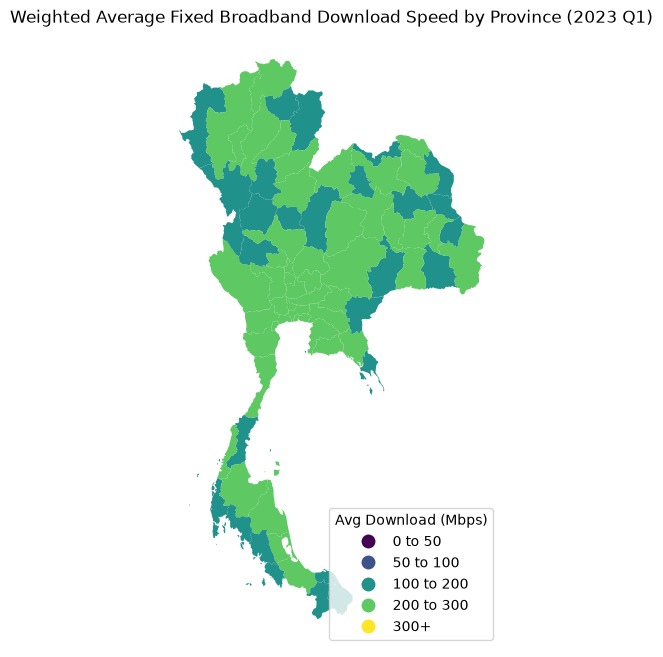

In [11]:
fig, ax = plt.subplots(1, figsize=(10, 8))
province_data.plot("group", ax=ax, legend=True, cmap="viridis", 
                   legend_kwds={'title': "Avg Download (Mbps)", 'loc': 'lower right'})

ax.set_title("Weighted Average Fixed Broadband Download Speed by Province (2023 Q1)")
ax.set_axis_off()
plt.show()

In [12]:
import pandas as pd

file_path = "/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/ookla/raw/2023-Q1_performance_fixed_tiles.parquet"
df = pd.read_parquet(file_path, engine='pyarrow')

In [13]:
df.head() 

,quadkey,tile,tile_x,tile_y,avg_d_kbps,avg_u_kbps,avg_lat_ms,avg_lat_down_ms,avg_lat_up_ms,tests,devices
0,0022022300231020,"POLYGON((-178.4619140625 70.9847699889061, -17...",-178.4592,70.9839,87,204,578,3627.0,3312.0,1,1
1,0022133222312322,"POLYGON((-160.02685546875 70.6435894914449, -1...",-160.0241,70.6427,158237,9571,170,517.0,257.0,5,2
2,0022133222330012,"POLYGON((-160.037841796875 70.6399478155463, -...",-160.0351,70.6390,74693,28236,164,590.0,243.0,2,1
3,0022133222330023,"POLYGON((-160.043334960938 70.6363054807905, -...",-160.0406,70.6354,69368,7703,251,546.0,590.0,2,1
4,0022133222330030,"POLYGON((-160.037841796875 70.6381267305321, -...",-160.0351,70.6372,259,260,32,310.0,426.0,1,1


In [14]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6336489 entries, 0 to 6336488
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   quadkey          str    
 1   tile             str    
 2   tile_x           float64
 3   tile_y           float64
 4   avg_d_kbps       int64  
 5   avg_u_kbps       int64  
 6   avg_lat_ms       int64  
 7   avg_lat_down_ms  float64
 8   avg_lat_up_ms    float64
 9   tests            int64  
 10  devices          int64  
dtypes: float64(4), int64(5), str(2)
memory usage: 1.7 GB
None


---
## Province Reference Data

Province-level context for EDA:
- **Population** (Dec 2024, Dept of Provincial Administration)
- **Area & Density** (Wikipedia)
- **GDP per capita** (2021 NESDC via thaiwebsites.com)
- **internet_tier** — proxy assumption based on GDP/density/region:
  - 1 = highest expected speed (Bangkok metro, EEC industrial zones, Phuket)
  - 2 = above average (major tourism hubs, Bangkok vicinity, high-GDP eastern)
  - 3 = average (provincial capitals, moderate GDP)
  - 4 = below average expected (Isaan, deep South border provinces, remote mountain provinces)

**National context (2023–2024):**
- Fixed BB: 15.75 subscribers per 100 people nationally
- Avg national fixed download: ~237 Mbps (13th globally)
- Urban internet usage: 92% | Rural: 85%
- Major ISPs: AIS (~4.7M subs), True Online (~3.8M subs)


In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

PROVINCE_REF_PATH = '/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/reference/province_reference.csv'

prov_ref = pd.read_csv(PROVINCE_REF_PATH)
prov_ref['gdp_per_capita_usd_2021'] = (prov_ref['gdp_per_capita_thb_2021'] / 31.0).round(0)

print(f"Provinces loaded: {len(prov_ref)}")
print(f"Regions: {sorted(prov_ref['region'].unique())}")
print()
print(prov_ref[['province_en','region','pop_2024','density_per_km2','gdp_per_capita_thb_2021','internet_tier']].to_string(index=False))


Provinces loaded: 77
Regions: ['Bangkok & Vicinity', 'Central', 'Eastern', 'Northeastern', 'Northern', 'Southern', 'Western']

             province_en             region  pop_2024  density_per_km2  gdp_per_capita_thb_2021  internet_tier
      Bangkok Metropolis Bangkok & Vicinity   5456000             3488                   593927              1
           Amnat Charoen       Northeastern    372000              113                    77048              4
               Ang Thong            Central    269000              283                   142287              3
               Bueng Kan       Northeastern    419000              105                    80159              4
                Buri Ram       Northeastern   1566000              155                    80684              4
            Chachoengsao            Eastern    733000              142                   400385              2
                Chai Nat            Central    314000              131                   135667 

### Population and GDP by Region — Summary

In [16]:
region_summary = (
    prov_ref.groupby('region')
    .agg(
        provinces=('province_en', 'count'),
        total_pop=('pop_2024', 'sum'),
        avg_density=('density_per_km2', 'mean'),
        avg_gdp_per_cap_thb=('gdp_per_capita_thb_2021', 'mean'),
        avg_gdp_per_cap_usd=('gdp_per_capita_usd_2021', 'mean'),
    )
    .sort_values('avg_gdp_per_cap_thb', ascending=False)
    .round(0)
)

region_summary['total_pop_M'] = (region_summary['total_pop'] / 1e6).round(2)
print(region_summary[['provinces','total_pop_M','avg_density','avg_gdp_per_cap_thb','avg_gdp_per_cap_usd']].to_string())


                    provinces  total_pop_M  avg_density  avg_gdp_per_cap_thb  avg_gdp_per_cap_usd
region                                                                                           
Eastern                     8         5.24        147.0             370345.0              11947.0
Bangkok & Vicinity          6        10.91       1490.0             331745.0              10701.0
Central                     6         2.97        212.0             225801.0               7284.0
Western                     6         3.81        163.0             158888.0               5125.0
Southern                   14         9.52        182.0             133270.0               4299.0
Northern                   17        11.89         72.0             108149.0               3489.0
Northeastern               20        21.62        129.0              85010.0               2742.0


### GDP per Capita vs Population Density — by Region

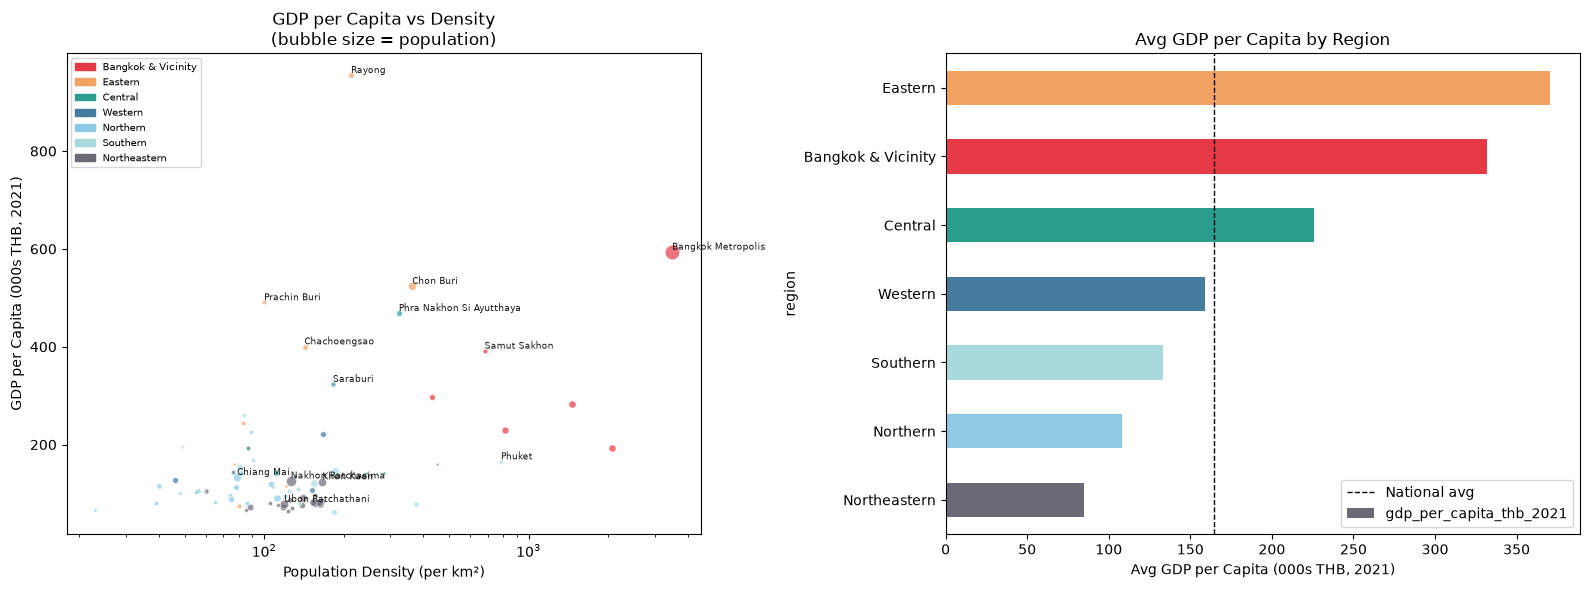

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_colors = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern':           '#f4a261',
    'Central':           '#2a9d8f',
    'Western':           '#457b9d',
    'Northern':          '#8ecae6',
    'Southern':          '#a8dadc',
    'Northeastern':      '#6d6875',
}

for _, row in prov_ref.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000,
                    color=c, alpha=0.7, s=row['pop_2024'] / 50000, edgecolors='white', linewidth=0.5)
    if row['gdp_per_capita_thb_2021'] > 300000 or row['province_en'] in ['Bangkok Metropolis','Phuket','Chiang Mai','Khon Kaen','Ubon Ratchathani','Nakhon Ratchasima']:
        axes[0].annotate(row['province_en'], (row['density_per_km2'], row['gdp_per_capita_thb_2021'] / 1000),
                         fontsize=6.5, ha='left', va='bottom', alpha=0.9)

axes[0].set_xlabel('Population Density (per km²)')
axes[0].set_ylabel('GDP per Capita (000s THB, 2021)')
axes[0].set_title('GDP per Capita vs Density\n(bubble size = population)')
axes[0].set_xscale('log')

# Bar chart: avg GDP per region
r_gdp = prov_ref.groupby('region')['gdp_per_capita_thb_2021'].mean().sort_values(ascending=True) / 1000
colors = [region_colors.get(r, 'gray') for r in r_gdp.index]
r_gdp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_xlabel('Avg GDP per Capita (000s THB, 2021)')
axes[1].set_title('Avg GDP per Capita by Region')
axes[1].axvline(prov_ref['gdp_per_capita_thb_2021'].mean() / 1000, color='black', linestyle='--', linewidth=1, label='National avg')
axes[1].legend()

patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
axes[0].legend(handles=patches, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()


### Internet Tier Distribution — Assumptions Map

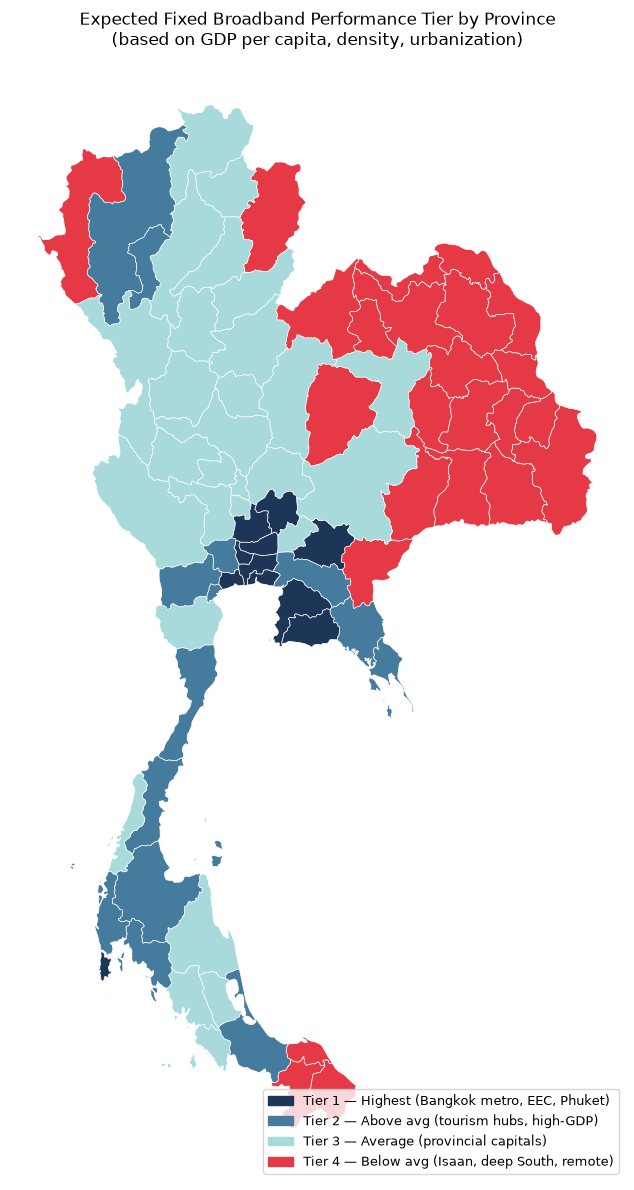

In [18]:
THAILAND_GEOJSON = '/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/geo/thailand_provinces.geojson'
thailand_gdf = gpd.read_file(THAILAND_GEOJSON).to_crs(4326)

# Merge — GeoJSON uses 'name' column
tier_map = prov_ref[['province_en','internet_tier','gdp_per_capita_thb_2021','region']].copy()

# Manual name alignment between GeoJSON and our CSV
name_map = {
    'Phra Nakhon Si Ayutthaya': 'Phra Nakhon Si Ayutthaya',
}

geo_with_tier = thailand_gdf.merge(
    tier_map.rename(columns={'province_en': 'name'}),
    on='name', how='left'
)

missing = geo_with_tier[geo_with_tier['internet_tier'].isna()]['name'].tolist()
if missing:
    print("Unmatched provinces (need manual fix):", missing)

tier_colors = {1: '#1d3557', 2: '#457b9d', 3: '#a8dadc', 4: '#e63946'}
geo_with_tier['tier_color'] = geo_with_tier['internet_tier'].map(tier_colors)

fig, ax = plt.subplots(1, figsize=(10, 12))
geo_with_tier.plot(color=geo_with_tier['tier_color'].fillna('lightgray'), ax=ax, edgecolor='white', linewidth=0.5)

patches = [
    mpatches.Patch(color='#1d3557', label='Tier 1 — Highest (Bangkok metro, EEC, Phuket)'),
    mpatches.Patch(color='#457b9d', label='Tier 2 — Above avg (tourism hubs, high-GDP)'),
    mpatches.Patch(color='#a8dadc', label='Tier 3 — Average (provincial capitals)'),
    mpatches.Patch(color='#e63946', label='Tier 4 — Below avg (Isaan, deep South, remote)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_title('Expected Fixed Broadband Performance Tier by Province\n(based on GDP per capita, density, urbanization)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


### Top & Bottom Provinces by GDP per Capita — with Internet Tier

In [19]:
top10 = prov_ref.nlargest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]
bot10 = prov_ref.nsmallest(10, 'gdp_per_capita_thb_2021')[['province_en','region','pop_2024','gdp_per_capita_thb_2021','internet_tier']]

print("=== TOP 10 by GDP per Capita ===")
print(top10.to_string(index=False))
print()
print("=== BOTTOM 10 by GDP per Capita ===")
print(bot10.to_string(index=False))


=== TOP 10 by GDP per Capita ===
             province_en             region  pop_2024  gdp_per_capita_thb_2021  internet_tier
                  Rayong            Eastern    782000                   955119              1
      Bangkok Metropolis Bangkok & Vicinity   5456000                   593927              1
               Chon Buri            Eastern   1636000                   524002              1
            Prachin Buri            Eastern    501000                   490499              1
Phra Nakhon Si Ayutthaya            Central    823000                   468579              1
            Chachoengsao            Eastern    733000                   400385              2
            Samut Sakhon Bangkok & Vicinity    591000                   391442              1
                Saraburi            Central    639000                   323556              1
           Nakhon Pathom Bangkok & Vicinity    926000                   297901              2
            Samut Prakan Ba

---
## Full EDA — Ookla Fixed Broadband, Thailand (2023 Q1 – 2025 Q4)


### 1. Load & Aggregate All Quarters

In [20]:
import glob, os, warnings
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy import stats
warnings.filterwarnings('ignore')

DATASET_DIR = '/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/ookla/raw'
GEOJSON     = '/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/geo/thailand_provinces.geojson'
PROV_REF    = '/home/chissanupun/Desktop/Code/other/LAB/CNC/DS/Internet-mersurement/data/reference/province_reference.csv'

# Ookla S3 filename convention: {YEAR}-{MM}-01_performance_fixed_tiles.parquet
# Q1=January(01), Q2=April(04), Q3=July(07), Q4=October(10)
Q_TO_MONTH = {1: 1, 2: 4, 3: 7, 4: 10}

thailand_gdf = gpd.read_file(GEOJSON).to_crs(4326)
state_bounds = thailand_gdf.total_bounds
bbox_filters = [
    ('tile_y', '<=', state_bounds[3]), ('tile_y', '>=', state_bounds[1]),
    ('tile_x', '<=', state_bounds[2]), ('tile_x', '>=', state_bounds[0]),
]

COLS = ['tile_x','tile_y','tests','devices','avg_d_kbps','avg_u_kbps','avg_lat_ms']

records = []
files = sorted(glob.glob(os.path.join(DATASET_DIR, '*.parquet')))

for fp in files:
    fname   = os.path.basename(fp)
    year    = int(fname[:4])
    quarter = int(fname[6])
    month   = Q_TO_MONTH[quarter]
    # period_start mirrors Ookla's original filename date (first day of the quarter)
    period_start = pd.Timestamp(year=year, month=month, day=1)
    label   = f"{year}-Q{quarter}"

    raw = pd.read_parquet(fp, columns=COLS, filters=bbox_filters)

    tiles_gdf = gpd.GeoDataFrame(
        raw,
        geometry=gpd.points_from_xy(raw.tile_x, raw.tile_y),
        crs='EPSG:4326'
    ).drop(columns=['tile_x','tile_y'])

    joined = gpd.sjoin(tiles_gdf, thailand_gdf[['name','geometry']], how='inner', predicate='intersects')

    agg = (
        joined.groupby('name')
        .apply(lambda g: pd.Series({
            'avg_d_kbps_wt': np.average(g['avg_d_kbps'], weights=g['tests']),
            'avg_u_kbps_wt': np.average(g['avg_u_kbps'], weights=g['tests']),
            'avg_lat_ms_wt': np.average(g['avg_lat_ms'], weights=g['tests']),
            'total_tests'  : g['tests'].sum(),
            'total_devices': g['devices'].sum(),
            'n_tiles'      : len(g),
        }), include_groups=False)
        .reset_index()
    )
    agg['year']         = year
    agg['quarter']      = quarter
    agg['month']        = month
    agg['period_start'] = period_start   # datetime: 2023-01-01, 2023-04-01, ...
    agg['label']        = label
    records.append(agg)
    print(f"  {label} ({period_start.date()}): {len(raw):>8,} raw tiles → {len(agg)} provinces")

master = pd.concat(records, ignore_index=True)
master['avg_d_mbps'] = master['avg_d_kbps_wt'] / 1000
master['avg_u_mbps'] = master['avg_u_kbps_wt'] / 1000
master.drop(columns=['avg_d_kbps_wt','avg_u_kbps_wt'], inplace=True)

# Merge province reference
prov_ref = pd.read_csv(PROV_REF)
prov_ref['gdp_per_capita_usd'] = (prov_ref['gdp_per_capita_thb_2021'] / 31).round(0)
master = master.merge(prov_ref.rename(columns={'province_en':'name'}), on='name', how='left')

print(f"\nMaster shape: {master.shape}")
print(f"Date range: {master['period_start'].min().date()} → {master['period_start'].max().date()}")
print(f"Quarters:   {sorted(master['label'].unique())}")
print(f"Provinces:  {master['name'].nunique()}")
print(f"\nperiod_start unique values (matches Ookla filename dates):")
for d in sorted(master['period_start'].unique()):
    print(f"  {pd.Timestamp(d).date()}")


  2023-Q1 (2023-01-01):  138,496 raw tiles → 77 provinces


  2023-Q2 (2023-04-01):  137,315 raw tiles → 77 provinces


  2023-Q3 (2023-07-01):  139,321 raw tiles → 77 provinces


  2023-Q4 (2023-10-01):  145,213 raw tiles → 77 provinces


  2024-Q1 (2024-01-01):  146,778 raw tiles → 77 provinces


...

  2024-Q4 (2024-10-01):  141,271 raw tiles → 77 provinces


  2025-Q1 (2025-01-01):  135,567 raw tiles → 77 provinces


  2025-Q2 (2025-04-01):  148,574 raw tiles → 77 provinces


  2025-Q4 (2025-10-01):  147,667 raw tiles → 77 provinces

Master shape: (847, 20)
Date range: 2023-01-01 → 2025-10-01


Quarters:   ['2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4', '2025-Q1', '2025-Q2', '2025-Q4']
Provinces:  77

period_start unique values (matches Ookla filename dates):
  2023-01-01
  2023-04-01
  2023-07-01
  2023-10-01
  2024-01-01
  2024-04-01
  2024-07-01
  2024-10-01
  2025-01-01
  2025-04-01
  2025-10-01


### 2. Data Quality — Coverage per Province

In [21]:
# Expected: 77 provinces × 11 quarters = 847 rows
expected = 77 * master['label'].nunique()
print(f"Expected rows: {expected} | Actual: {len(master)} | Missing: {expected - len(master)}")

# Provinces with zero coverage in any quarter
all_provinces = set(thailand_gdf['name'])
all_labels    = set(master['label'].unique())
coverage_pivot = master.pivot_table(index='name', columns='label', values='total_tests', aggfunc='sum')

missing_cells = [(p, q) for p in all_provinces for q in all_labels
                 if p not in coverage_pivot.index or pd.isna(coverage_pivot.loc[p, q])]
if missing_cells:
    print(f"\nMissing province-quarter combos ({len(missing_cells)}):")
    for p, q in missing_cells:
        print(f"  {p} — {q}")
else:
    print("\nAll 77 provinces covered in every quarter.")

# Low-test provinces (< 100 tests in any quarter)
low_test = master[master['total_tests'] < 100][['name','label','total_tests','n_tiles']].sort_values('total_tests')
if len(low_test):
    print(f"\nLow-test quarters (< 100 tests) — {len(low_test)} cases:")
    print(low_test.to_string(index=False))
else:
    print("\nNo quarters with < 100 tests.")


Expected rows: 847 | Actual: 847 | Missing: 0



All 77 provinces covered in every quarter.

No quarters with < 100 tests.


### 3. Speed Distribution — All Provinces, All Quarters

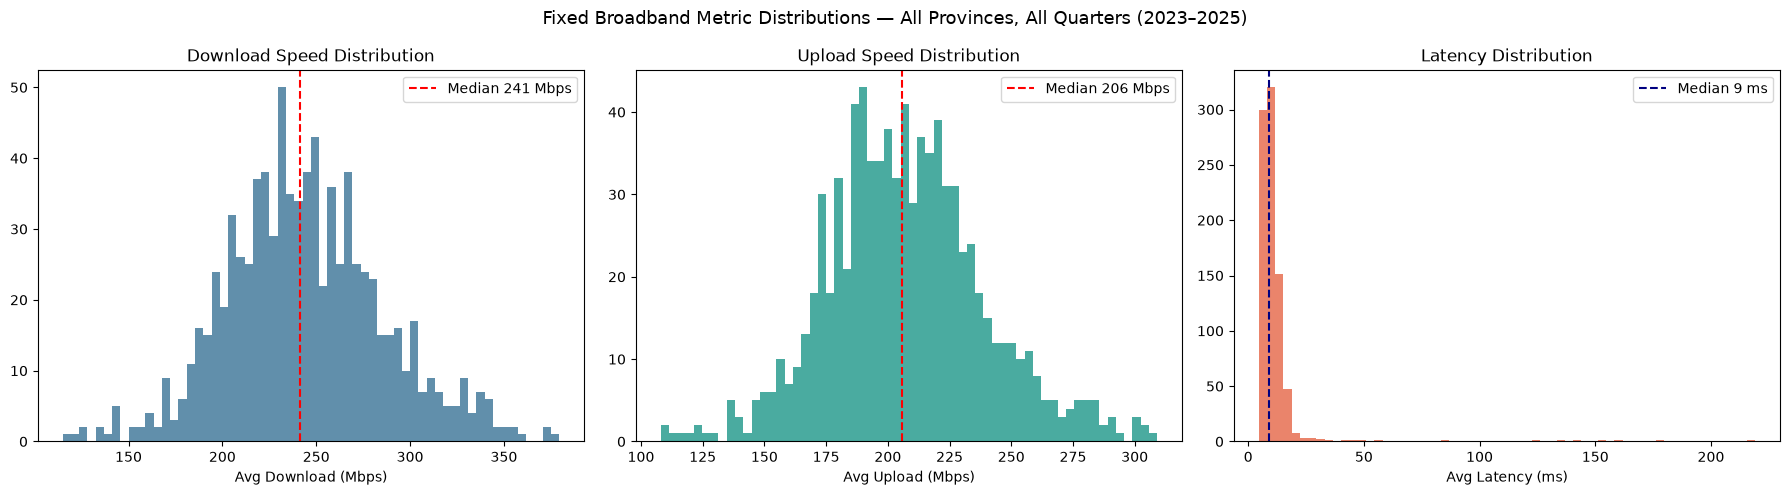

       avg_d_mbps  avg_u_mbps  avg_lat_ms_wt  total_tests
count      847.00      847.00         847.00       847.00
mean       244.19      207.19          11.28     22371.42
std         42.01       32.06          14.73     56482.32
min        114.85      107.93           4.48      1786.00
25%        216.81      186.73           6.88      5199.00
50%        241.29      205.69           9.16      9427.00
75%        269.36      226.07          11.85     19160.00
max        379.43      309.10         219.10    526178.00


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(master['avg_d_mbps'].dropna(), bins=60, color='#457b9d', edgecolor='none', alpha=0.85)
axes[0].axvline(master['avg_d_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_d_mbps"].median():.0f} Mbps')
axes[0].set_xlabel('Avg Download (Mbps)'); axes[0].set_title('Download Speed Distribution'); axes[0].legend()

axes[1].hist(master['avg_u_mbps'].dropna(), bins=60, color='#2a9d8f', edgecolor='none', alpha=0.85)
axes[1].axvline(master['avg_u_mbps'].median(), color='red', ls='--', lw=1.5, label=f'Median {master["avg_u_mbps"].median():.0f} Mbps')
axes[1].set_xlabel('Avg Upload (Mbps)'); axes[1].set_title('Upload Speed Distribution'); axes[1].legend()

axes[2].hist(master['avg_lat_ms_wt'].dropna(), bins=60, color='#e76f51', edgecolor='none', alpha=0.85)
axes[2].axvline(master['avg_lat_ms_wt'].median(), color='navy', ls='--', lw=1.5, label=f'Median {master["avg_lat_ms_wt"].median():.0f} ms')
axes[2].set_xlabel('Avg Latency (ms)'); axes[2].set_title('Latency Distribution'); axes[2].legend()

plt.suptitle('Fixed Broadband Metric Distributions — All Provinces, All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()
plt.show()

print(master[['avg_d_mbps','avg_u_mbps','avg_lat_ms_wt','total_tests']].describe().round(2))


### 4. Province Ranking — Mean Download Speed (All Quarters)

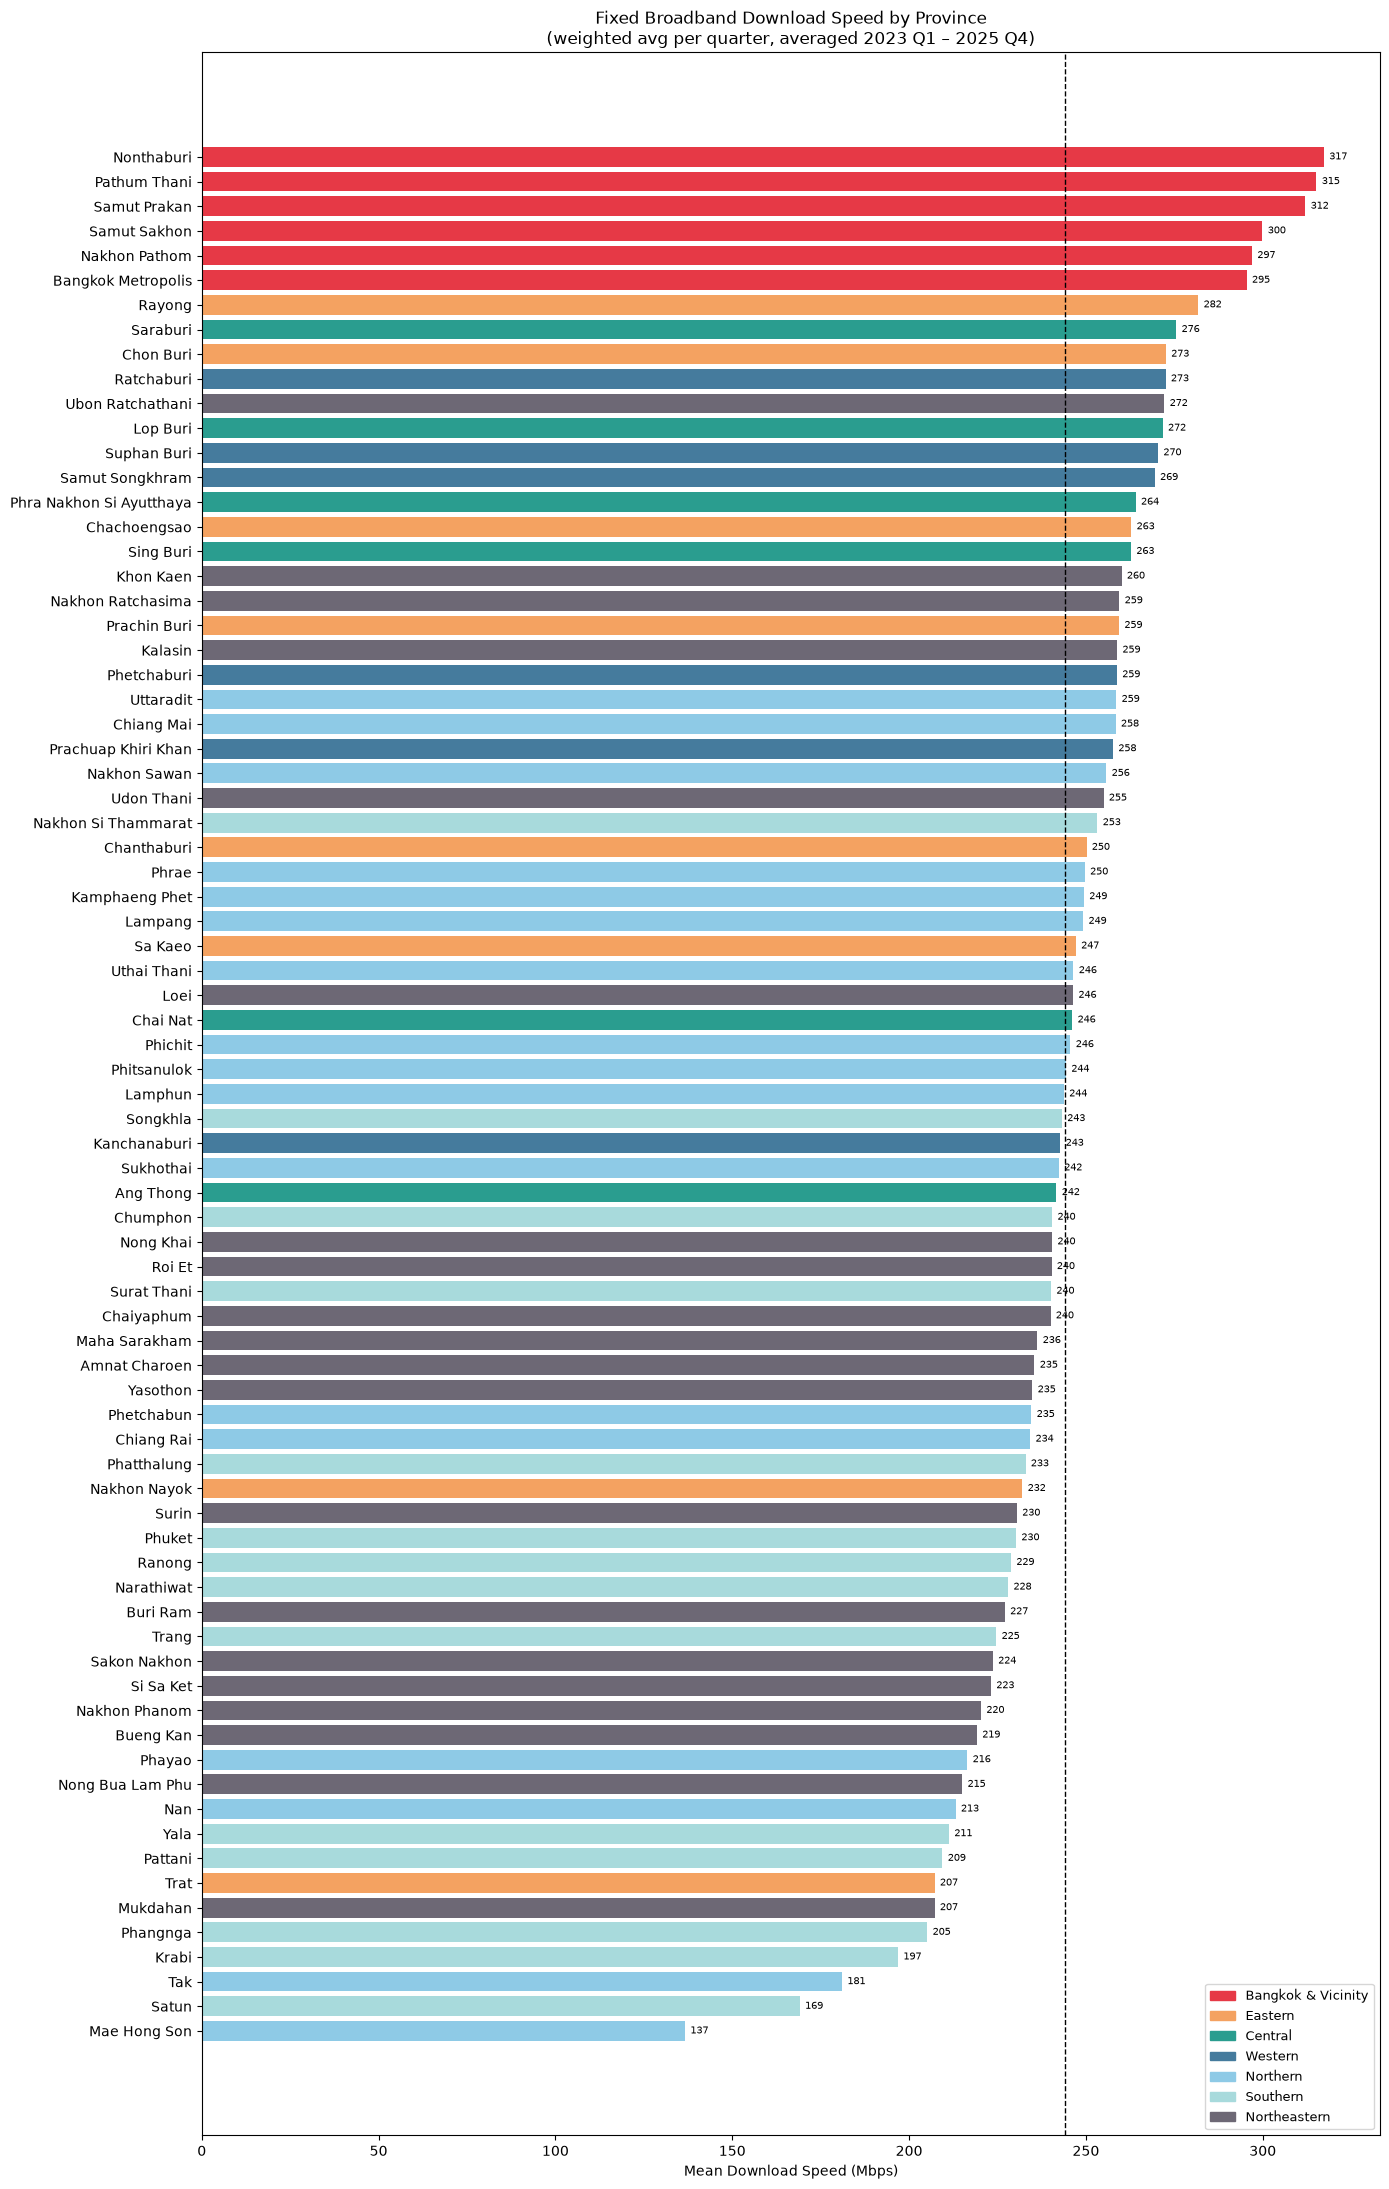

In [23]:
region_colors = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern':            '#f4a261',
    'Central':            '#2a9d8f',
    'Western':            '#457b9d',
    'Northern':           '#8ecae6',
    'Southern':           '#a8dadc',
    'Northeastern':       '#6d6875',
}

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=True)
)

fig, ax = plt.subplots(figsize=(14, 22))
colors = [region_colors.get(r,'gray') for r in prov_mean['region']]
bars = ax.barh(prov_mean['name'], prov_mean['mean_dl'], color=colors, edgecolor='none')

# Add value labels
for bar, val in zip(bars, prov_mean['mean_dl']):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=7)

ax.axvline(prov_mean['mean_dl'].mean(), color='black', ls='--', lw=1, label=f'National mean {prov_mean["mean_dl"].mean():.0f} Mbps')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)
ax.set_xlabel('Mean Download Speed (Mbps)')
ax.set_title('Fixed Broadband Download Speed by Province\n(weighted avg per quarter, averaged 2023 Q1 – 2025 Q4)', fontsize=12)
plt.tight_layout()
plt.show()


### 5. Time Series — Download Speed Heatmap (Province × Quarter)

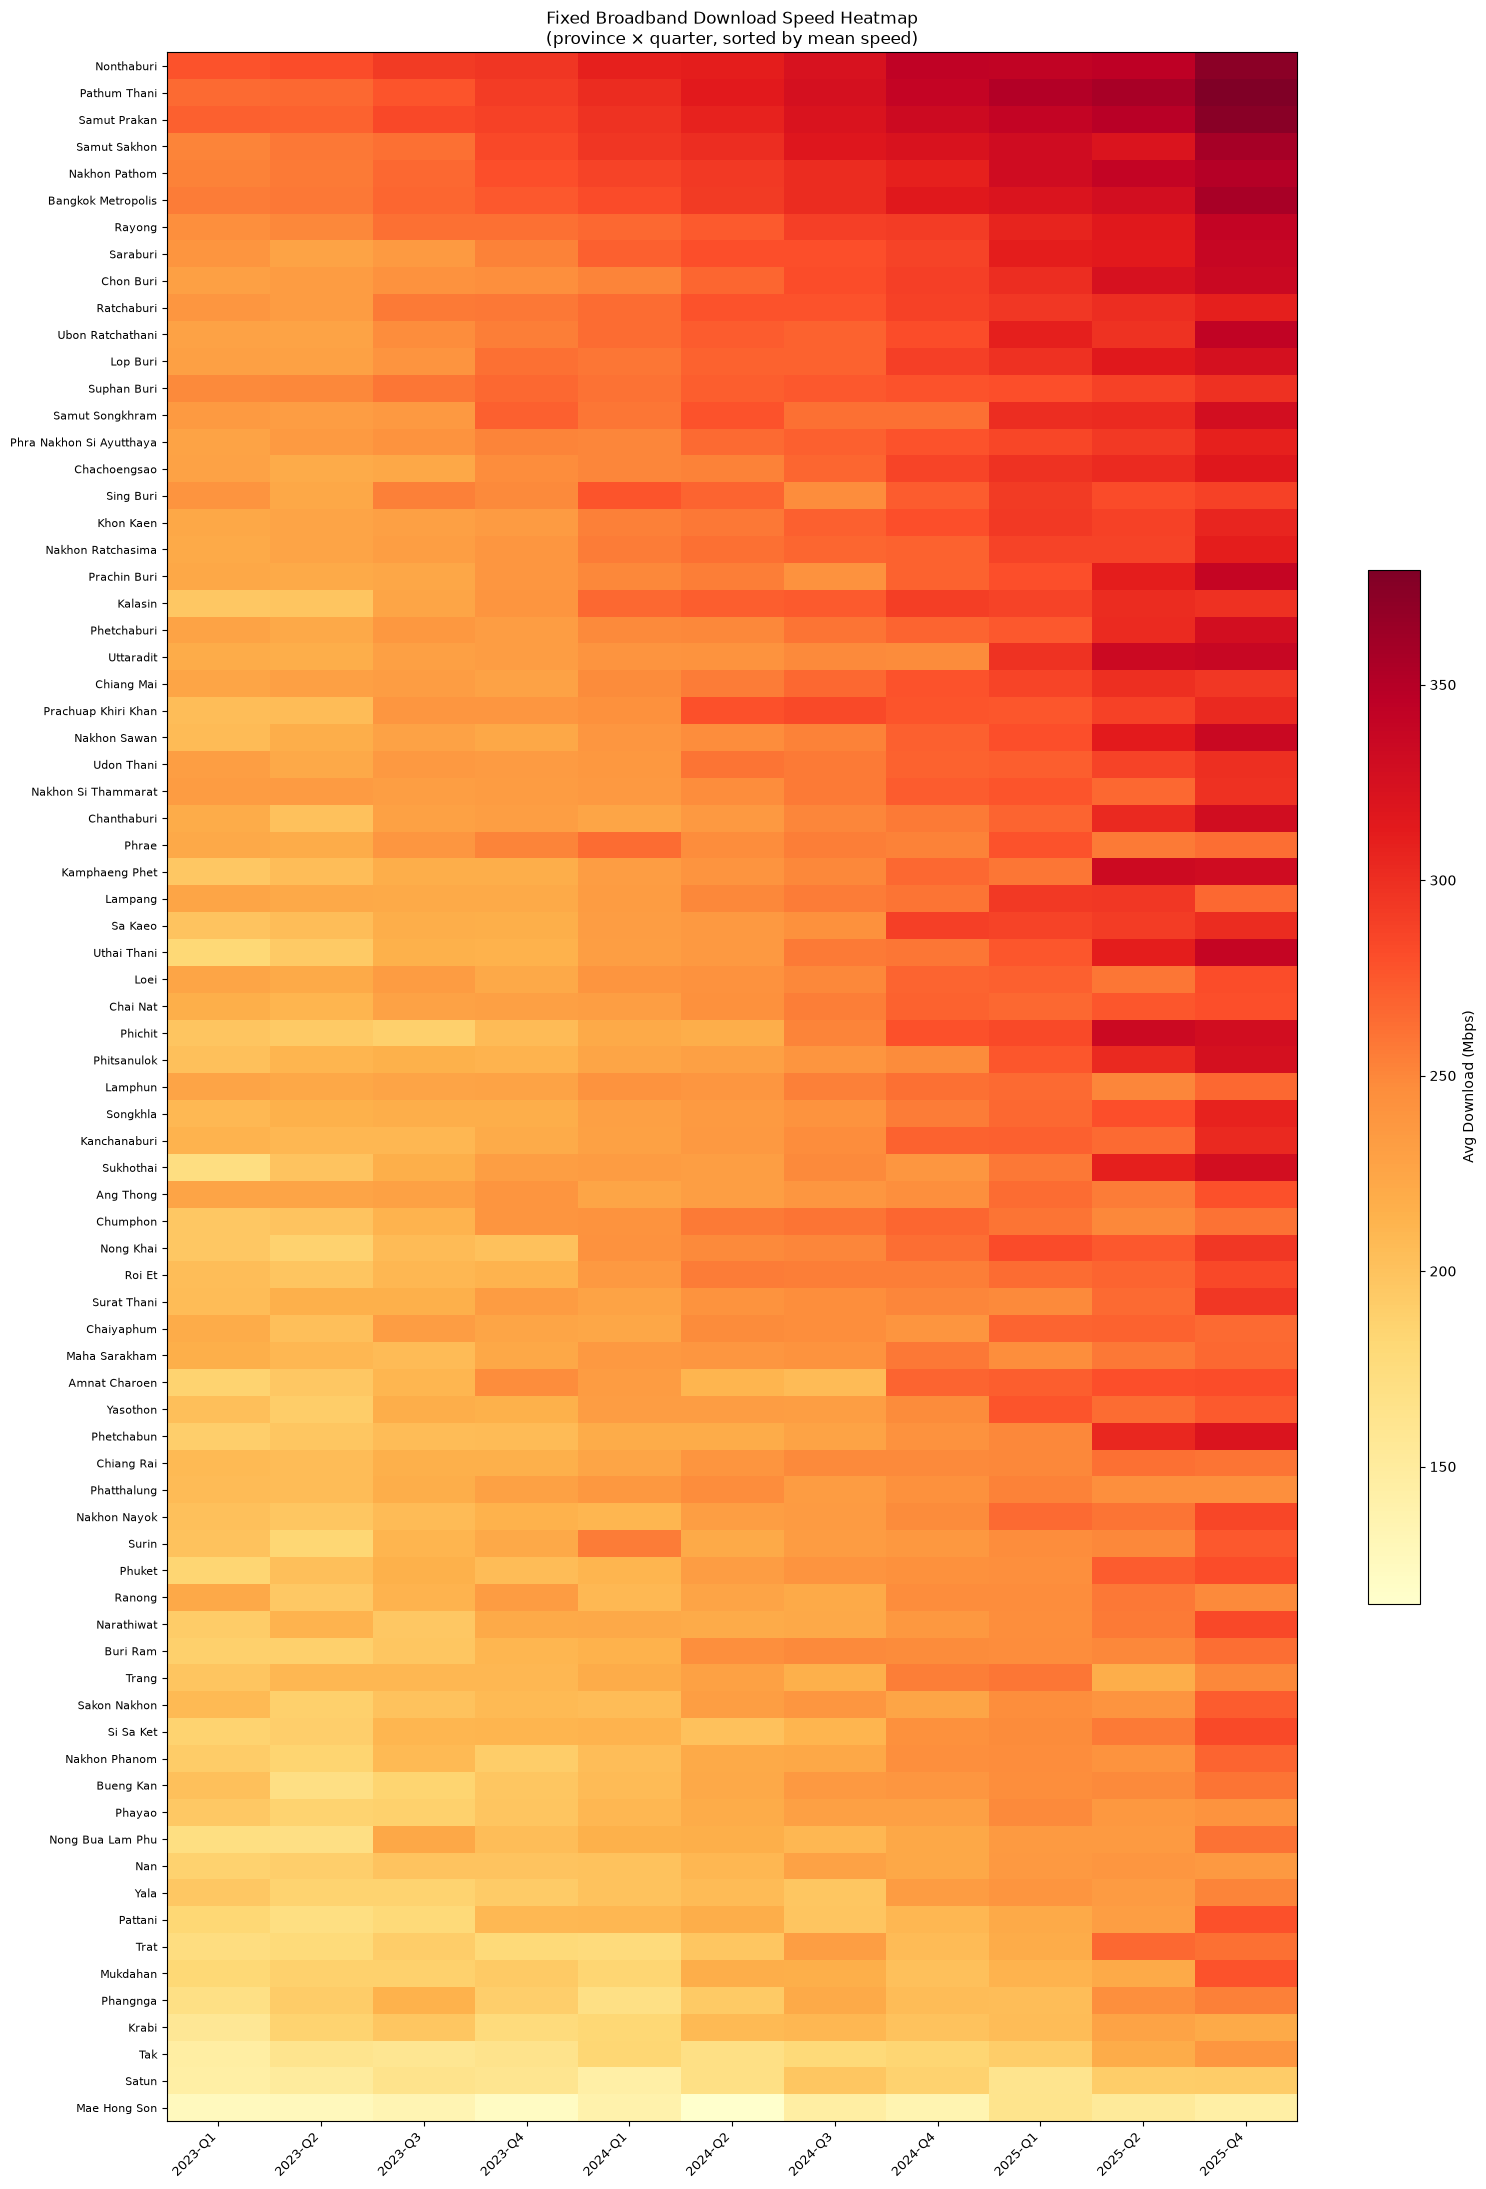

In [24]:
pivot_dl = master.pivot_table(index='name', columns='period_start', values='avg_d_mbps')
# Format column labels as quarter strings for display
pivot_dl.columns = [pd.Timestamp(c).strftime('%Y-Q') + str((pd.Timestamp(c).month-1)//3+1) for c in pivot_dl.columns]
# Sort by mean download speed
pivot_dl = pivot_dl.loc[prov_mean.sort_values('mean_dl', ascending=False)['name']]

fig, ax = plt.subplots(figsize=(16, 22))
im = ax.imshow(pivot_dl.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
plt.colorbar(im, ax=ax, label='Avg Download (Mbps)', shrink=0.5)

ax.set_xticks(range(len(pivot_dl.columns)))
ax.set_xticklabels(pivot_dl.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_dl.index)))
ax.set_yticklabels(pivot_dl.index, fontsize=8)
ax.set_title('Fixed Broadband Download Speed Heatmap\n(province × quarter, sorted by mean speed)', fontsize=12)
plt.tight_layout()
plt.show()


### 6. Regional Comparison — Download, Upload, Latency

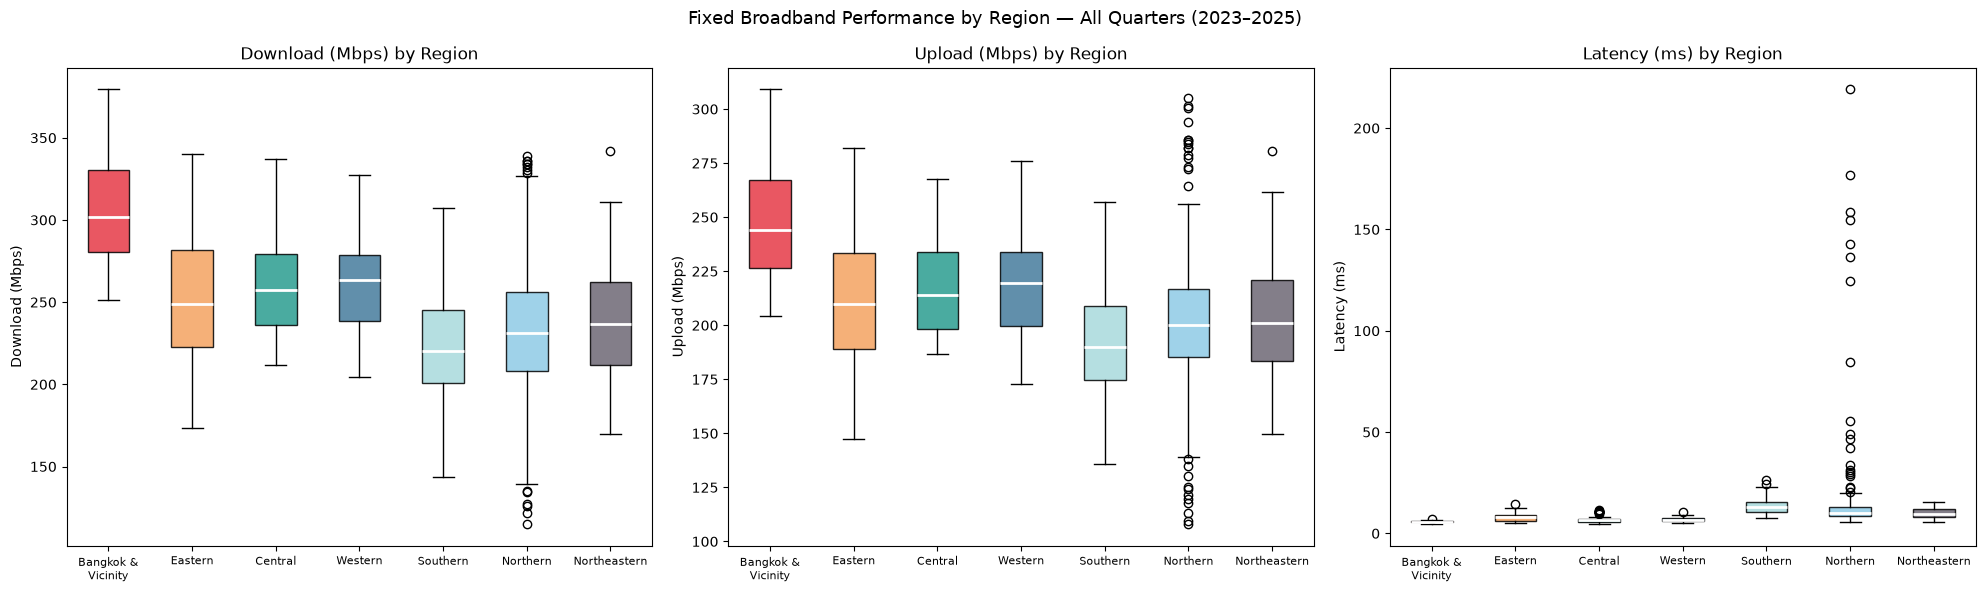

In [25]:
region_order = ['Bangkok & Vicinity','Eastern','Central','Western','Southern','Northern','Northeastern']
region_data  = [master[master['region']==r]['avg_d_mbps'].dropna().values for r in region_order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, metric, label, color_key in [
    (axes[0], 'avg_d_mbps',   'Download (Mbps)', '#457b9d'),
    (axes[1], 'avg_u_mbps',   'Upload (Mbps)',   '#2a9d8f'),
    (axes[2], 'avg_lat_ms_wt','Latency (ms)',    '#e76f51'),
]:
    data = [master[master['region']==r][metric].dropna().values for r in region_order]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color='white', linewidth=2))
    for patch, region in zip(bp['boxes'], region_order):
        patch.set_facecolor(region_colors[region])
        patch.set_alpha(0.85)
    ax.set_xticklabels([r.replace(' & ',' &\n') for r in region_order], fontsize=8)
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Region')

plt.suptitle('Fixed Broadband Performance by Region — All Quarters (2023–2025)', fontsize=13)
plt.tight_layout()
plt.show()


### 7. Download Speed Trend — Top, Bottom & Interesting Provinces

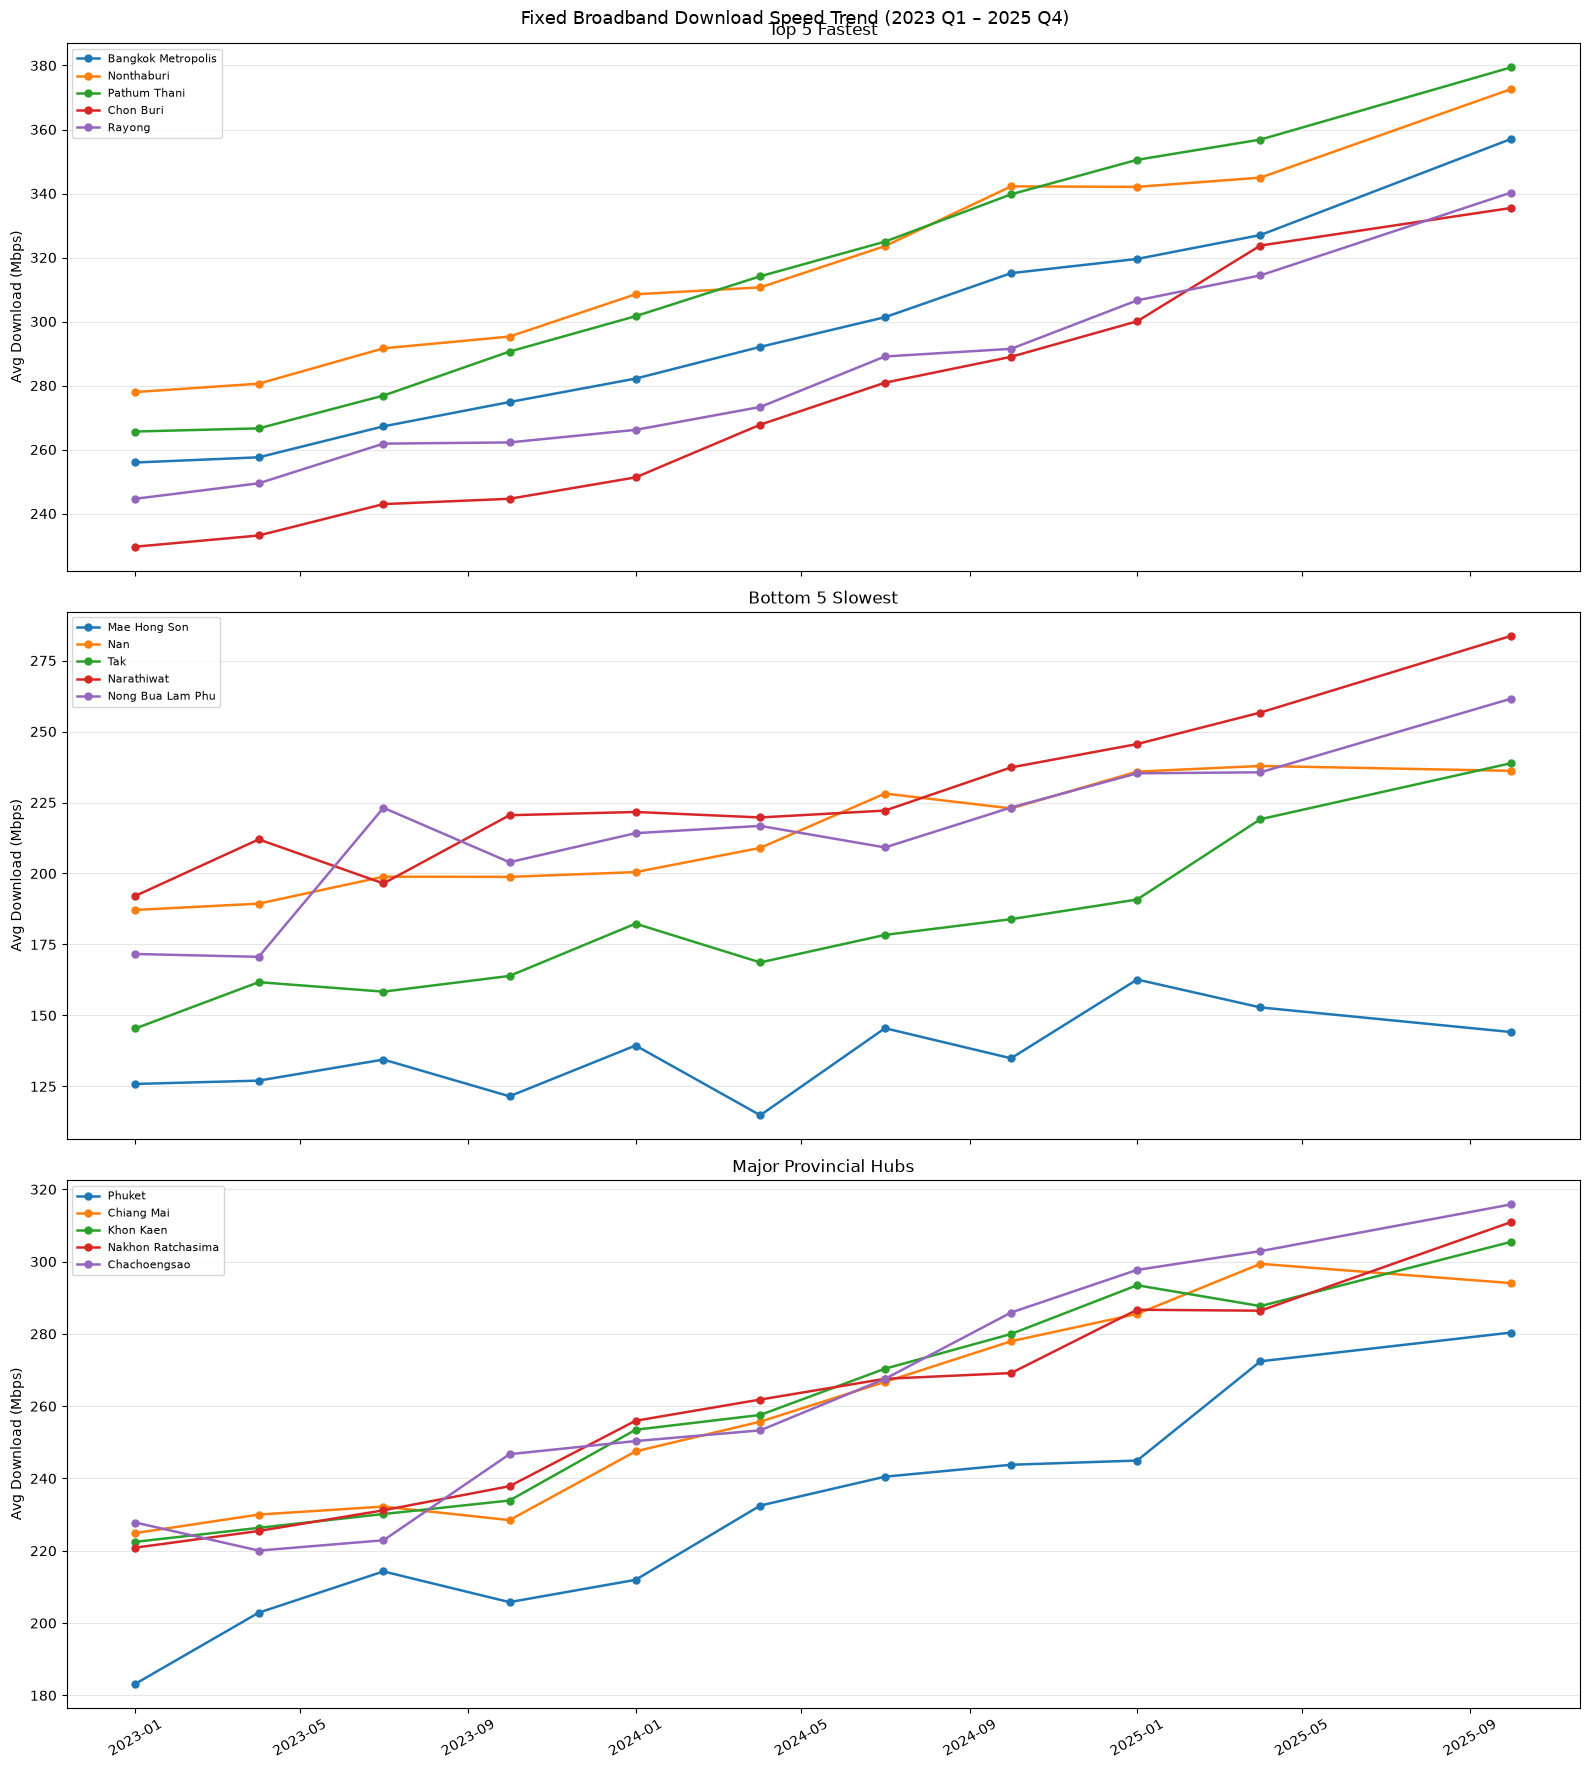

In [26]:
HIGHLIGHT = [
    # Top performers
    'Bangkok Metropolis','Nonthaburi','Pathum Thani','Chon Buri','Rayong',
    # Bottom performers  
    'Mae Hong Son','Nan','Tak','Narathiwat','Nong Bua Lam Phu',
    # Interesting (high GDP mismatch or border)
    'Phuket','Chiang Mai','Khon Kaen','Nakhon Ratchasima',
]

quarter_order = sorted(master['label'].unique())
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

groups = [
    ('Top 5 Fastest', ['Bangkok Metropolis','Nonthaburi','Pathum Thani','Chon Buri','Rayong'], '#e63946'),
    ('Bottom 5 Slowest', ['Mae Hong Son','Nan','Tak','Narathiwat','Nong Bua Lam Phu'], '#6d6875'),
    ('Major Provincial Hubs', ['Phuket','Chiang Mai','Khon Kaen','Nakhon Ratchasima','Chachoengsao'], '#f4a261'),
]

for ax, (title, provinces, base_color) in zip(axes, groups):
    for i, prov in enumerate(provinces):
        df_p = master[master['name']==prov].sort_values('label')
        if df_p.empty: continue
        ax.plot(df_p['period_start'], df_p['avg_d_mbps'], marker='o', markersize=5,
                label=prov, linewidth=1.8)
    ax.set_ylabel('Avg Download (Mbps)')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Fixed Broadband Download Speed Trend (2023 Q1 – 2025 Q4)', fontsize=13)
plt.tight_layout()
plt.show()


### 8. GDP per Capita vs Download Speed — Does Money = Speed?

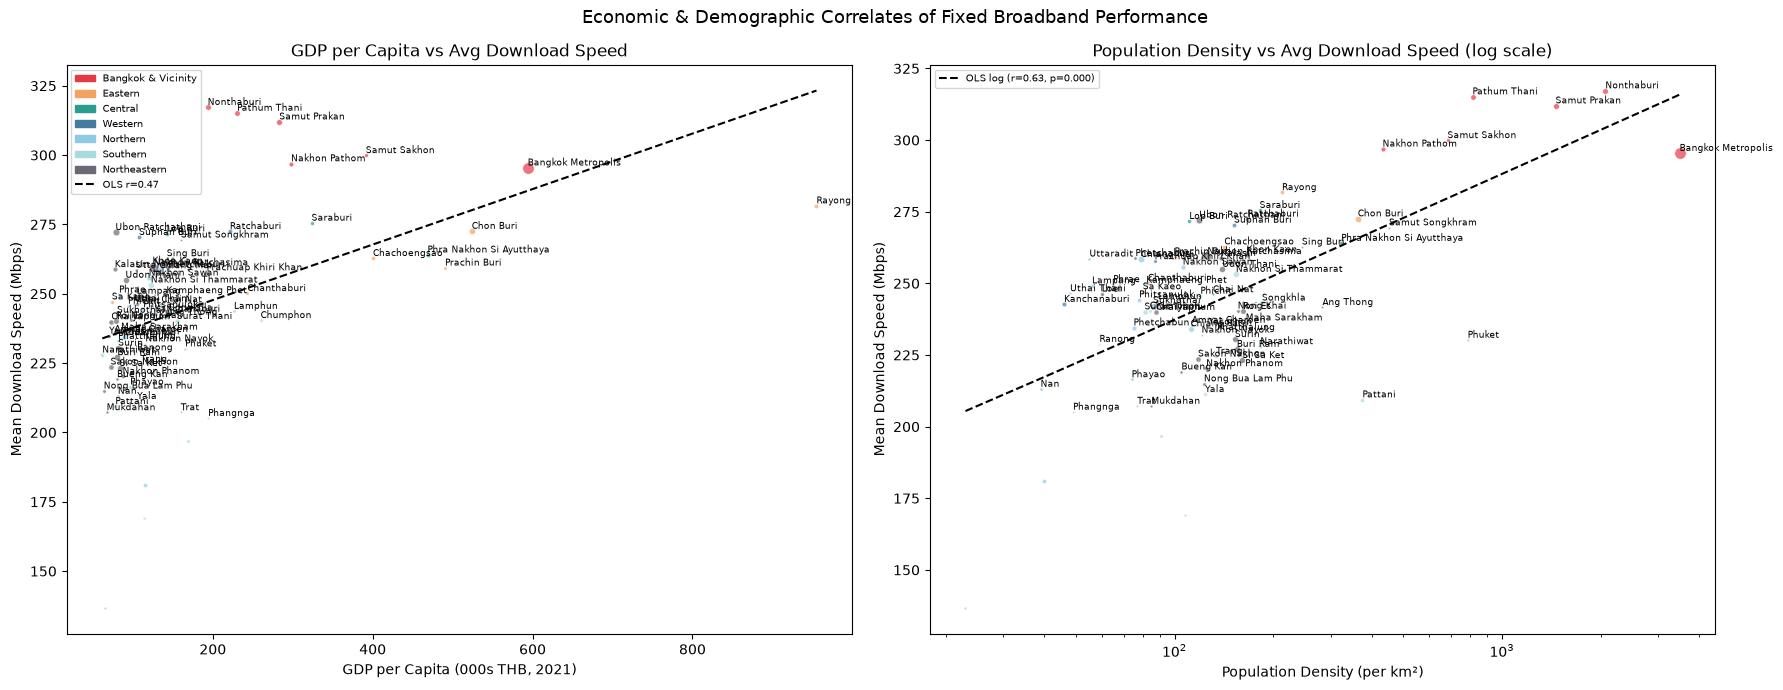

Pearson r (GDP vs download):     0.475  p=0.0000
Pearson r (log density vs download): 0.629  p=0.0000


In [27]:
corr_df = prov_mean.merge(
    prov_ref[['province_en','gdp_per_capita_thb_2021','internet_tier','pop_2024','density_per_km2']].rename(columns={'province_en':'name'}),
    on='name', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: GDP vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'], 'gray')
    axes[0].scatter(row['gdp_per_capita_thb_2021']/1000, row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    # Label outliers
    if row['gdp_per_capita_thb_2021'] > 350000 or row['mean_dl'] > 200 or row['mean_dl'] < 60:
        axes[0].annotate(row['name'], (row['gdp_per_capita_thb_2021']/1000, row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

# OLS trendline
x = corr_df['gdp_per_capita_thb_2021'].dropna()/1000
y = corr_df.loc[x.index,'mean_dl']
slope, intercept, r, p, _ = stats.linregress(x, y)
xline = np.linspace(x.min(), x.max(), 100)
axes[0].plot(xline, slope*xline+intercept, 'k--', lw=1.5, label=f'OLS (r={r:.2f}, p={p:.3f})')
axes[0].set_xlabel('GDP per Capita (000s THB, 2021)')
axes[0].set_ylabel('Mean Download Speed (Mbps)')
axes[0].set_title('GDP per Capita vs Avg Download Speed')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches+[plt.Line2D([0],[0],color='k',ls='--',label=f'OLS r={r:.2f}')], fontsize=7)

# Scatter: density vs download
for _, row in corr_df.iterrows():
    c = region_colors.get(row['region'],'gray')
    axes[1].scatter(row['density_per_km2'], row['mean_dl'],
                    color=c, s=row['pop_2024']/80000, alpha=0.7, edgecolors='white', lw=0.5)
    if row['density_per_km2'] > 500 or row['mean_dl'] > 200 or row['mean_dl'] < 60:
        axes[1].annotate(row['name'], (row['density_per_km2'], row['mean_dl']),
                         fontsize=6.5, ha='left', va='bottom')

x2 = corr_df['density_per_km2'].dropna()
y2 = corr_df.loc[x2.index,'mean_dl']
s2,i2,r2,p2,_ = stats.linregress(np.log1p(x2), y2)
xline2 = np.linspace(x2.min(), x2.max(), 200)
axes[1].plot(xline2, s2*np.log1p(xline2)+i2, 'k--', lw=1.5, label=f'OLS log (r={r2:.2f}, p={p2:.3f})')
axes[1].set_xlabel('Population Density (per km²)')
axes[1].set_xscale('log')
axes[1].set_ylabel('Mean Download Speed (Mbps)')
axes[1].set_title('Population Density vs Avg Download Speed (log scale)')
axes[1].legend(fontsize=7)

plt.suptitle('Economic & Demographic Correlates of Fixed Broadband Performance', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Pearson r (GDP vs download):     {r:.3f}  p={p:.4f}")
print(f"Pearson r (log density vs download): {r2:.3f}  p={p2:.4f}")


### 9. Upload/Download Ratio — Symmetry Check

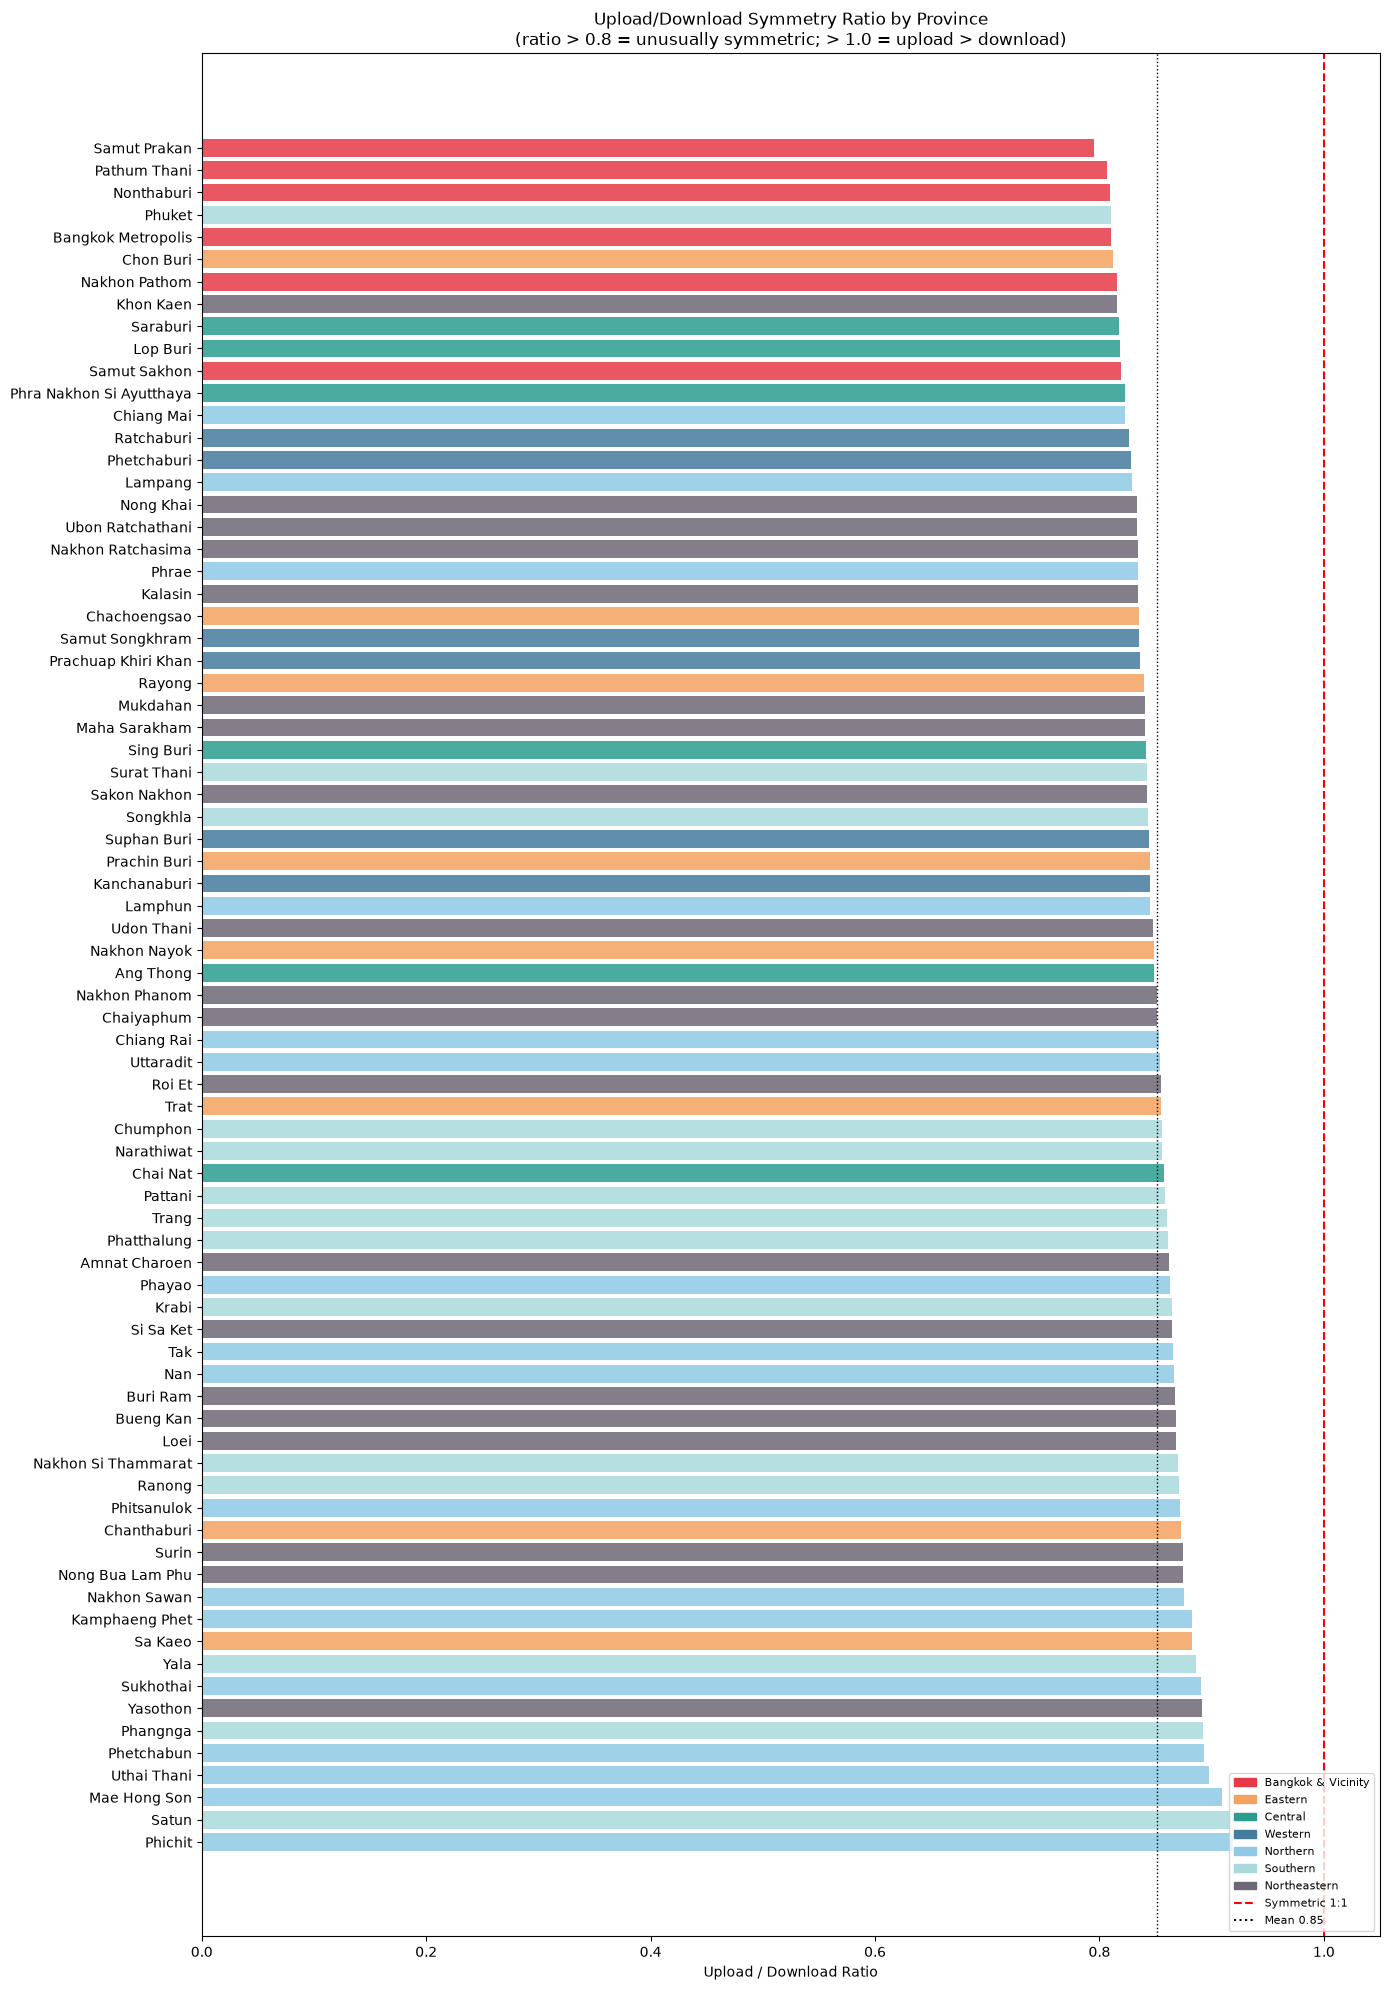

Provinces with UL/DL ratio > 0.8 (76):
                    name             region  ul_dl_ratio
                 Phichit           Northern     0.918945
                   Satun           Southern     0.917170
            Mae Hong Son           Northern     0.909214
             Uthai Thani           Northern     0.897268
              Phetchabun           Northern     0.893416
                Phangnga           Southern     0.892131
                Yasothon       Northeastern     0.891742
               Sukhothai           Northern     0.890411
                    Yala           Southern     0.885886
                 Sa Kaeo            Eastern     0.882778
          Kamphaeng Phet           Northern     0.882724
            Nakhon Sawan           Northern     0.875629
        Nong Bua Lam Phu       Northeastern     0.874272
                   Surin       Northeastern     0.874198
             Chanthaburi            Eastern     0.872919
             Phitsanulok           Northern     0

In [28]:
master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']

ratio_mean = master.groupby('name')['ul_dl_ratio'].mean().sort_values(ascending=False).reset_index()
ratio_mean = ratio_mean.merge(prov_ref[['province_en','region']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in ratio_mean['region']]
ax.barh(ratio_mean['name'], ratio_mean['ul_dl_ratio'], color=colors, alpha=0.85)
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Symmetric (1:1)')
ax.axvline(ratio_mean['ul_dl_ratio'].mean(), color='black', ls=':', lw=1, label=f'Mean ratio {ratio_mean["ul_dl_ratio"].mean():.2f}')
ax.set_xlabel('Upload / Download Ratio')
ax.set_title('Upload/Download Symmetry Ratio by Province\n(ratio > 0.8 = unusually symmetric; > 1.0 = upload > download)')
patches = [mpatches.Patch(color=v, label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[
    plt.Line2D([0],[0],color='red',ls='--',label='Symmetric 1:1'),
    plt.Line2D([0],[0],color='black',ls=':',label=f'Mean {ratio_mean["ul_dl_ratio"].mean():.2f}')
], fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

weird_ratio = ratio_mean[ratio_mean['ul_dl_ratio'] > 0.8]
print(f"Provinces with UL/DL ratio > 0.8 ({len(weird_ratio)}):")
print(weird_ratio[['name','region','ul_dl_ratio']].to_string(index=False))


### 10. Anomaly Detection — Province Flags

In [29]:
# === ANOMALY DETECTION (recalibrated from actual data) ===
# National mean UL/DL ratio = 0.852 → flag only clear outliers (z-score based)
# Tier medians are compressed: T1=282, T2=247, T3=246, T4=229 Mbps
# Thresholds set based on observed distributions

from scipy import stats
import numpy as np

master['ul_dl_ratio'] = master['avg_u_mbps'] / master['avg_d_mbps']
high_ratio = master.groupby('name')['ul_dl_ratio'].mean()

prov_mean = (
    master.groupby(['name','region'])
    .agg(
        mean_dl=('avg_d_mbps','mean'),
        mean_ul=('avg_u_mbps','mean'),
        mean_lat=('avg_lat_ms_wt','mean'),
        mean_tests=('total_tests','mean'),
        mean_ratio=('ul_dl_ratio','mean'),
    )
    .reset_index()
    .sort_values('mean_dl', ascending=False)
)
prov_mean['tier'] = prov_mean['name'].map(prov_ref.set_index('province_en')['internet_tier'].to_dict())

tier_speed   = prov_mean.groupby('tier')['mean_dl'].median()
national_std = prov_mean['mean_dl'].std()

flags = {}

# ── Flag A: Low coverage ───────────────────────────────────────────────────────
for _, row in master[master['total_tests'] < 200].iterrows():
    flags.setdefault(row['name'], []).append(
        f"LOW_COVERAGE ({row['label']}: {row['total_tests']:.0f} tests)")

# ── Flag B: Tier mismatch ──────────────────────────────────────────────────────
for _, row in prov_mean.iterrows():
    tier = row['tier']
    if pd.isna(tier): continue
    # Tier 1 province below Tier 3 median
    if tier == 1 and row['mean_dl'] < tier_speed[3]:
        flags.setdefault(row['name'], []).append(
            f"TIER1_UNDERPERFORM ({row['mean_dl']:.0f} Mbps < Tier3 median {tier_speed[3]:.0f})")
    # Tier 4 province well above Tier 2 median (>1 std above)
    if tier == 4 and row['mean_dl'] > tier_speed[2] + 0.5*national_std:
        flags.setdefault(row['name'], []).append(
            f"TIER4_OVERPERFORM ({row['mean_dl']:.0f} Mbps >> Tier2 median {tier_speed[2]:.0f})")

# ── Flag C: QoQ spike >50% ────────────────────────────────────────────────────
for prov, grp in master.sort_values('label').groupby('name'):
    dl = grp['avg_d_mbps'].values
    lbls = grp['label'].values
    for i in range(1, len(dl)):
        if dl[i-1] > 0:
            pct = abs(dl[i]-dl[i-1]) / dl[i-1]
            if pct > 0.50:
                flags.setdefault(prov, []).append(
                    f"QoQ_SPIKE ({lbls[i-1]}→{lbls[i]}: {dl[i-1]:.0f}→{dl[i]:.0f} Mbps, {pct*100:.0f}%)")

# ── Flag D: UL/DL ratio (z-score based — national mean 0.852) ─────────────────
ratio_vals = high_ratio.values
ratio_z    = stats.zscore(ratio_vals)
for (name, ratio), z in zip(high_ratio.items(), ratio_z):
    if z > 2.0:   # anomalously symmetric
        flags.setdefault(name, []).append(f"HIGH_UL_DL_RATIO (ratio={ratio:.2f}, z={z:.2f})")
    if z < -2.0:  # anomalously asymmetric
        flags.setdefault(name, []).append(f"LOW_UL_DL_RATIO (ratio={ratio:.2f}, z={z:.2f})")

# ── Flag E: Regional z-score outlier (|z| > 2.5) ─────────────────────────────
for region, grp in prov_mean.groupby('region'):
    if len(grp) < 4: continue
    z = stats.zscore(grp['mean_dl'].fillna(grp['mean_dl'].median()))
    for idx, zval in zip(grp.index, z):
        if abs(zval) > 2.5:
            name = grp.loc[idx,'name']
            flags.setdefault(name, []).append(
                f"REGIONAL_OUTLIER (z={zval:.2f} in {region}, {grp.loc[idx,'mean_dl']:.0f} Mbps)")

# ── Flag F: Latency anomaly ───────────────────────────────────────────────────
for _, row in prov_mean.iterrows():
    if row['mean_lat'] < 6:
        flags.setdefault(row['name'], []).append(
            f"ULTRA_LOW_LATENCY ({row['mean_lat']:.1f} ms — possible Ookla server collocation)")

# ── Flag G: Large 2023→2025 improvement (>35% download gain) ──────────────────
first_q = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last_q  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
for name in first_q.index:
    if name in last_q.index and first_q[name] > 0:
        pct = (last_q[name] - first_q[name]) / first_q[name]
        if pct > 0.35:
            flags.setdefault(name, []).append(
                f"RAPID_GROWTH (+{pct*100:.0f}% from 2023Q1 {first_q[name]:.0f}→2025Q4 {last_q[name]:.0f} Mbps)")
        if pct < -0.10:
            flags.setdefault(name, []).append(
                f"SPEED_DECLINE ({pct*100:.0f}% from 2023Q1 {first_q[name]:.0f}→2025Q4 {last_q[name]:.0f} Mbps)")

flag_counts = {name: len(flist) for name, flist in flags.items()}

print(f"=== FLAGGED PROVINCES ({len(flags)}) ===\n")
for name in sorted(flags.keys(), key=lambda x: -len(flags[x])):
    tier = prov_mean.loc[prov_mean['name']==name,'tier'].values
    speed = prov_mean.loc[prov_mean['name']==name,'mean_dl'].values
    t_str = str(int(tier[0])) if len(tier) else '?'
    s_str = f"{speed[0]:.0f} Mbps" if len(speed) else '?'
    print(f"** {name} | Tier {t_str} | {s_str} | {len(flags[name])} flags **")
    for f in flags[name]:
        print(f"   • {f}")
    print()


=== FLAGGED PROVINCES (52) ===

** Samut Prakan | Tier 1 | 312 Mbps | 3 flags **
   • LOW_UL_DL_RATIO (ratio=0.80, z=-2.14)
   • ULTRA_LOW_LATENCY (5.9 ms — possible Ookla server collocation)
   • RAPID_GROWTH (+39% from 2023Q1 270→2025Q4 374 Mbps)

** Ubon Ratchathani | Tier 4 | 272 Mbps | 2 flags **
   • TIER4_OVERPERFORM (272 Mbps >> Tier2 median 247)
   • RAPID_GROWTH (+50% from 2023Q1 228→2025Q4 342 Mbps)

** Phuket | Tier 1 | 230 Mbps | 2 flags **
   • TIER1_UNDERPERFORM (230 Mbps < Tier3 median 246)
   • RAPID_GROWTH (+53% from 2023Q1 183→2025Q4 280 Mbps)

** Mae Hong Son | Tier 4 | 137 Mbps | 2 flags **
   • HIGH_UL_DL_RATIO (ratio=0.91, z=2.18)
   • REGIONAL_OUTLIER (z=-3.14 in Northern, 137 Mbps)

** Phichit | Tier 3 | 246 Mbps | 2 flags **
   • HIGH_UL_DL_RATIO (ratio=0.92, z=2.55)
   • RAPID_GROWTH (+66% from 2023Q1 198→2025Q4 328 Mbps)

** Satun | Tier 3 | 169 Mbps | 2 flags **
   • HIGH_UL_DL_RATIO (ratio=0.92, z=2.48)
   • REGIONAL_OUTLIER (z=-2.50 in Southern, 169 Mbps)

### 11. Flagged Provinces Map

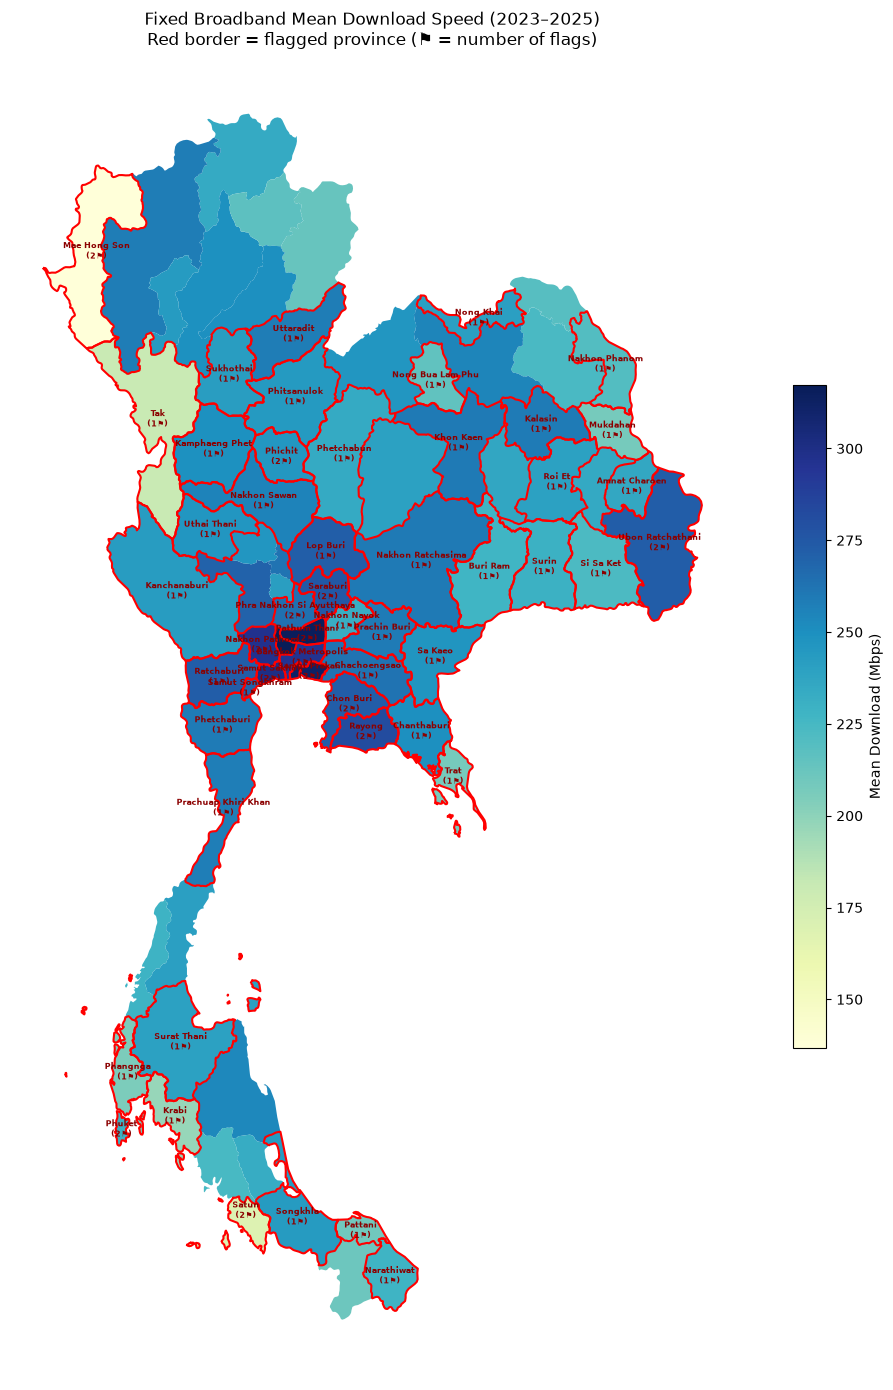

In [30]:
flag_counts = {name: len(flist) for name, flist in flags.items()}

geo_flags = thailand_gdf.copy()
geo_flags['flag_count'] = geo_flags['name'].map(flag_counts).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 14))

# Base: speed by province
speed_map = prov_mean.set_index('name')['mean_dl'].to_dict()
geo_flags['mean_dl'] = geo_flags['name'].map(speed_map)
geo_flags.plot('mean_dl', ax=ax, cmap='YlGnBu', legend=True, missing_kwds={'color':'lightgray'},
               legend_kwds={'label':'Mean Download (Mbps)','shrink':0.5})

# Overlay flagged provinces
geo_flagged = geo_flags[geo_flags['flag_count'] > 0]
geo_flagged.boundary.plot(ax=ax, color='red', linewidth=1.5)

# Label flagged provinces
for _, row in geo_flagged.iterrows():
    c = row.geometry.centroid
    ax.annotate(f"{row['name']}\n({row['flag_count']}⚑)",
                (c.x, c.y), ha='center', va='center', fontsize=5.5,
                color='darkred', fontweight='bold')

ax.set_title('Fixed Broadband Mean Download Speed (2023–2025)\nRed border = flagged province (⚑ = number of flags)', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()


### 12. Full Province Summary Table

In [31]:
summary = prov_mean.merge(
    prov_ref[['province_en','pop_2024','gdp_per_capita_thb_2021','internet_tier']].rename(columns={'province_en':'name'}),
    on='name', how='left'
).copy()

summary['flag_count'] = summary['name'].map(flag_counts).fillna(0).astype(int)
summary['ul_dl_ratio'] = summary['name'].map(high_ratio).round(3)
summary = summary.sort_values('mean_dl', ascending=False).round(2)

print(summary[[
    'name','region','internet_tier',
    'mean_dl','mean_ul','mean_lat',
    'ul_dl_ratio','mean_tests',
    'gdp_per_capita_thb_2021','flag_count'
]].to_string(index=False))

                    name             region  internet_tier  mean_dl  mean_ul  mean_lat  ul_dl_ratio  mean_tests  gdp_per_capita_thb_2021  flag_count
              Nonthaburi Bangkok & Vicinity              1   317.29   256.74      6.05         0.81    82461.00                   193641           0
            Pathum Thani Bangkok & Vicinity              1   315.19   254.39      5.35         0.81    73300.00                   230401           2
            Samut Prakan Bangkok & Vicinity              1   312.04   247.99      5.93         0.80    85336.36                   283160           3
            Samut Sakhon Bangkok & Vicinity              1   299.91   245.52      5.80         0.82    26094.27                   391442           2
           Nakhon Pathom Bangkok & Vicinity              2   296.97   241.86      5.45         0.82    33914.73                   297901           2
      Bangkok Metropolis Bangkok & Vicinity              1   295.46   239.28      6.28         0.81   4824

### 13. UL/DL Symmetry — Fiber Penetration Evidence

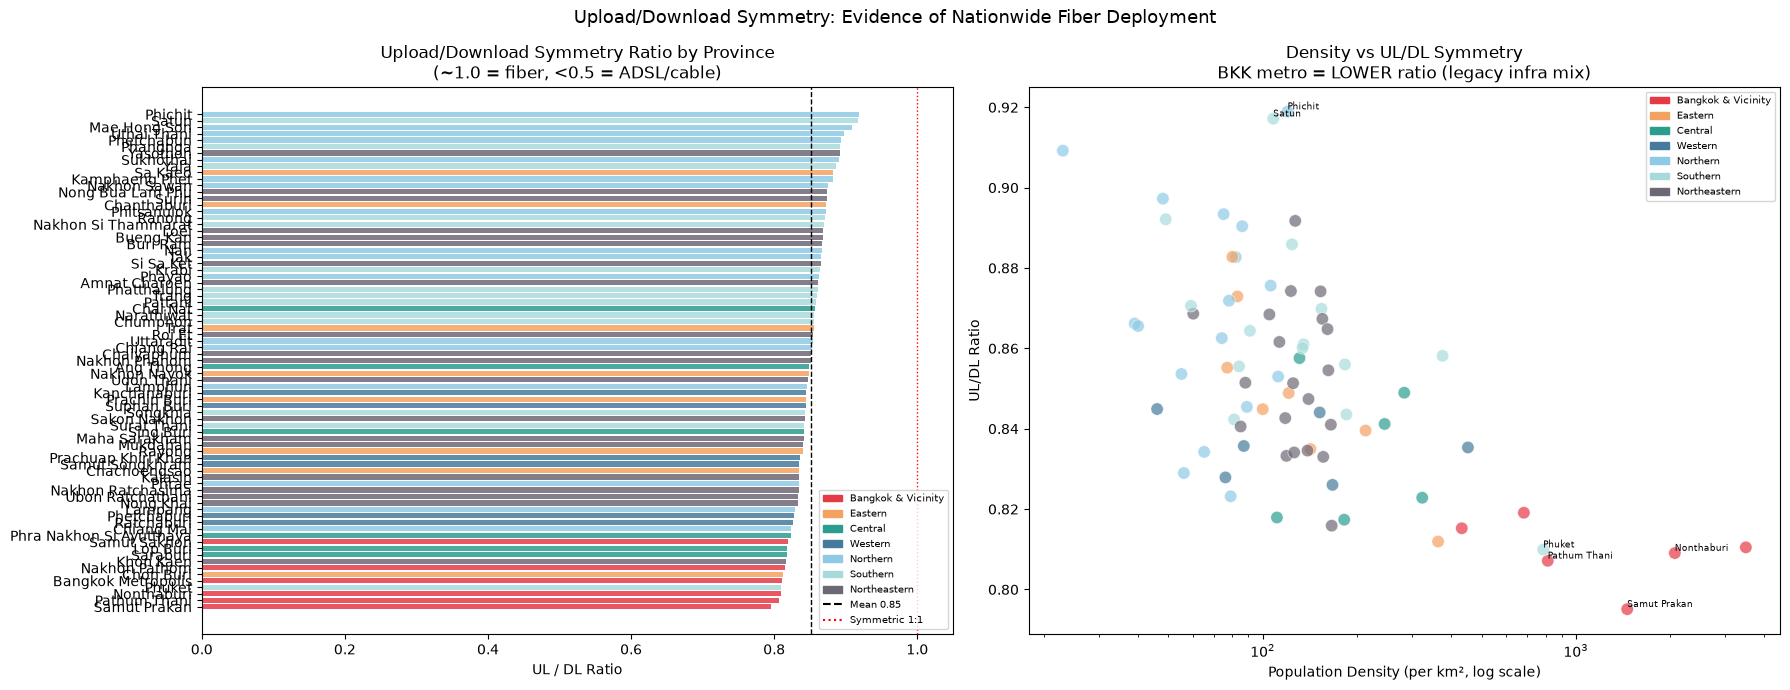

Provinces ratio > 0.90: 3 (near-perfect fiber)
Provinces ratio > 0.80: 76 out of 77
Bangkok metro min ratio: 0.795
Rural province max ratio: 0.892


In [32]:
# Near-symmetric UL/DL is a fiber hallmark (GPON/FTTH = ~1:1, ADSL = ~0.1-0.2)
# National mean = 0.852 → widespread fiber even in poor/rural provinces

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ratio_sorted = prov_mean.sort_values('mean_ratio', ascending=True)
colors = [region_colors.get(r,'gray') for r in ratio_sorted['region']]
axes[0].barh(ratio_sorted['name'], ratio_sorted['mean_ratio'], color=colors, alpha=0.85)
axes[0].axvline(prov_mean['mean_ratio'].mean(), color='black', ls='--', lw=1,
                label=f"National mean {prov_mean['mean_ratio'].mean():.2f}")
axes[0].axvline(1.0, color='red', ls=':', lw=1, label='Symmetric 1:1')
axes[0].set_xlabel('UL / DL Ratio')
axes[0].set_title('Upload/Download Symmetry Ratio by Province\n(~1.0 = fiber, <0.5 = ADSL/cable)')
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
axes[0].legend(handles=patches + [
    plt.Line2D([0],[0],color='black',ls='--',label=f'Mean {prov_mean["mean_ratio"].mean():.2f}'),
    plt.Line2D([0],[0],color='red',ls=':',label='Symmetric 1:1'),
], fontsize=7, loc='lower right')

# Bangkok vs rural: BKK has LOWER ratio (older infra mix) vs rural fiber-only
axes[1].scatter(prov_ref.set_index('province_en').loc[prov_mean['name'],'density_per_km2'].values,
                prov_mean['mean_ratio'].values,
                c=[region_colors.get(r,'gray') for r in prov_mean['region']],
                s=80, alpha=0.7, edgecolors='white', lw=0.5)
for _, row in prov_mean.iterrows():
    if row['mean_ratio'] > 0.91 or row['mean_ratio'] < 0.81 or row['mean_dl'] > 300:
        density = prov_ref.loc[prov_ref['province_en']==row['name'],'density_per_km2'].values
        if len(density):
            axes[1].annotate(row['name'], (density[0], row['mean_ratio']),
                             fontsize=6.5, ha='left', va='bottom')
axes[1].set_xscale('log')
axes[1].set_xlabel('Population Density (per km², log scale)')
axes[1].set_ylabel('UL/DL Ratio')
axes[1].set_title('Density vs UL/DL Symmetry\nBKK metro = LOWER ratio (legacy infra mix)')
axes[1].legend(handles=patches, fontsize=7)

plt.suptitle('Upload/Download Symmetry: Evidence of Nationwide Fiber Deployment', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Provinces ratio > 0.90: {(prov_mean['mean_ratio'] > 0.90).sum()} (near-perfect fiber)")
print(f"Provinces ratio > 0.80: {(prov_mean['mean_ratio'] > 0.80).sum()} out of 77")
print(f"Bangkok metro min ratio: {prov_mean[prov_mean['region']=='Bangkok & Vicinity']['mean_ratio'].min():.3f}")
print(f"Rural province max ratio: {prov_mean[prov_mean['region']=='Northeastern']['mean_ratio'].max():.3f}")


### 14. Temporal: Speed Growth 2023 Q1 → 2025 Q4

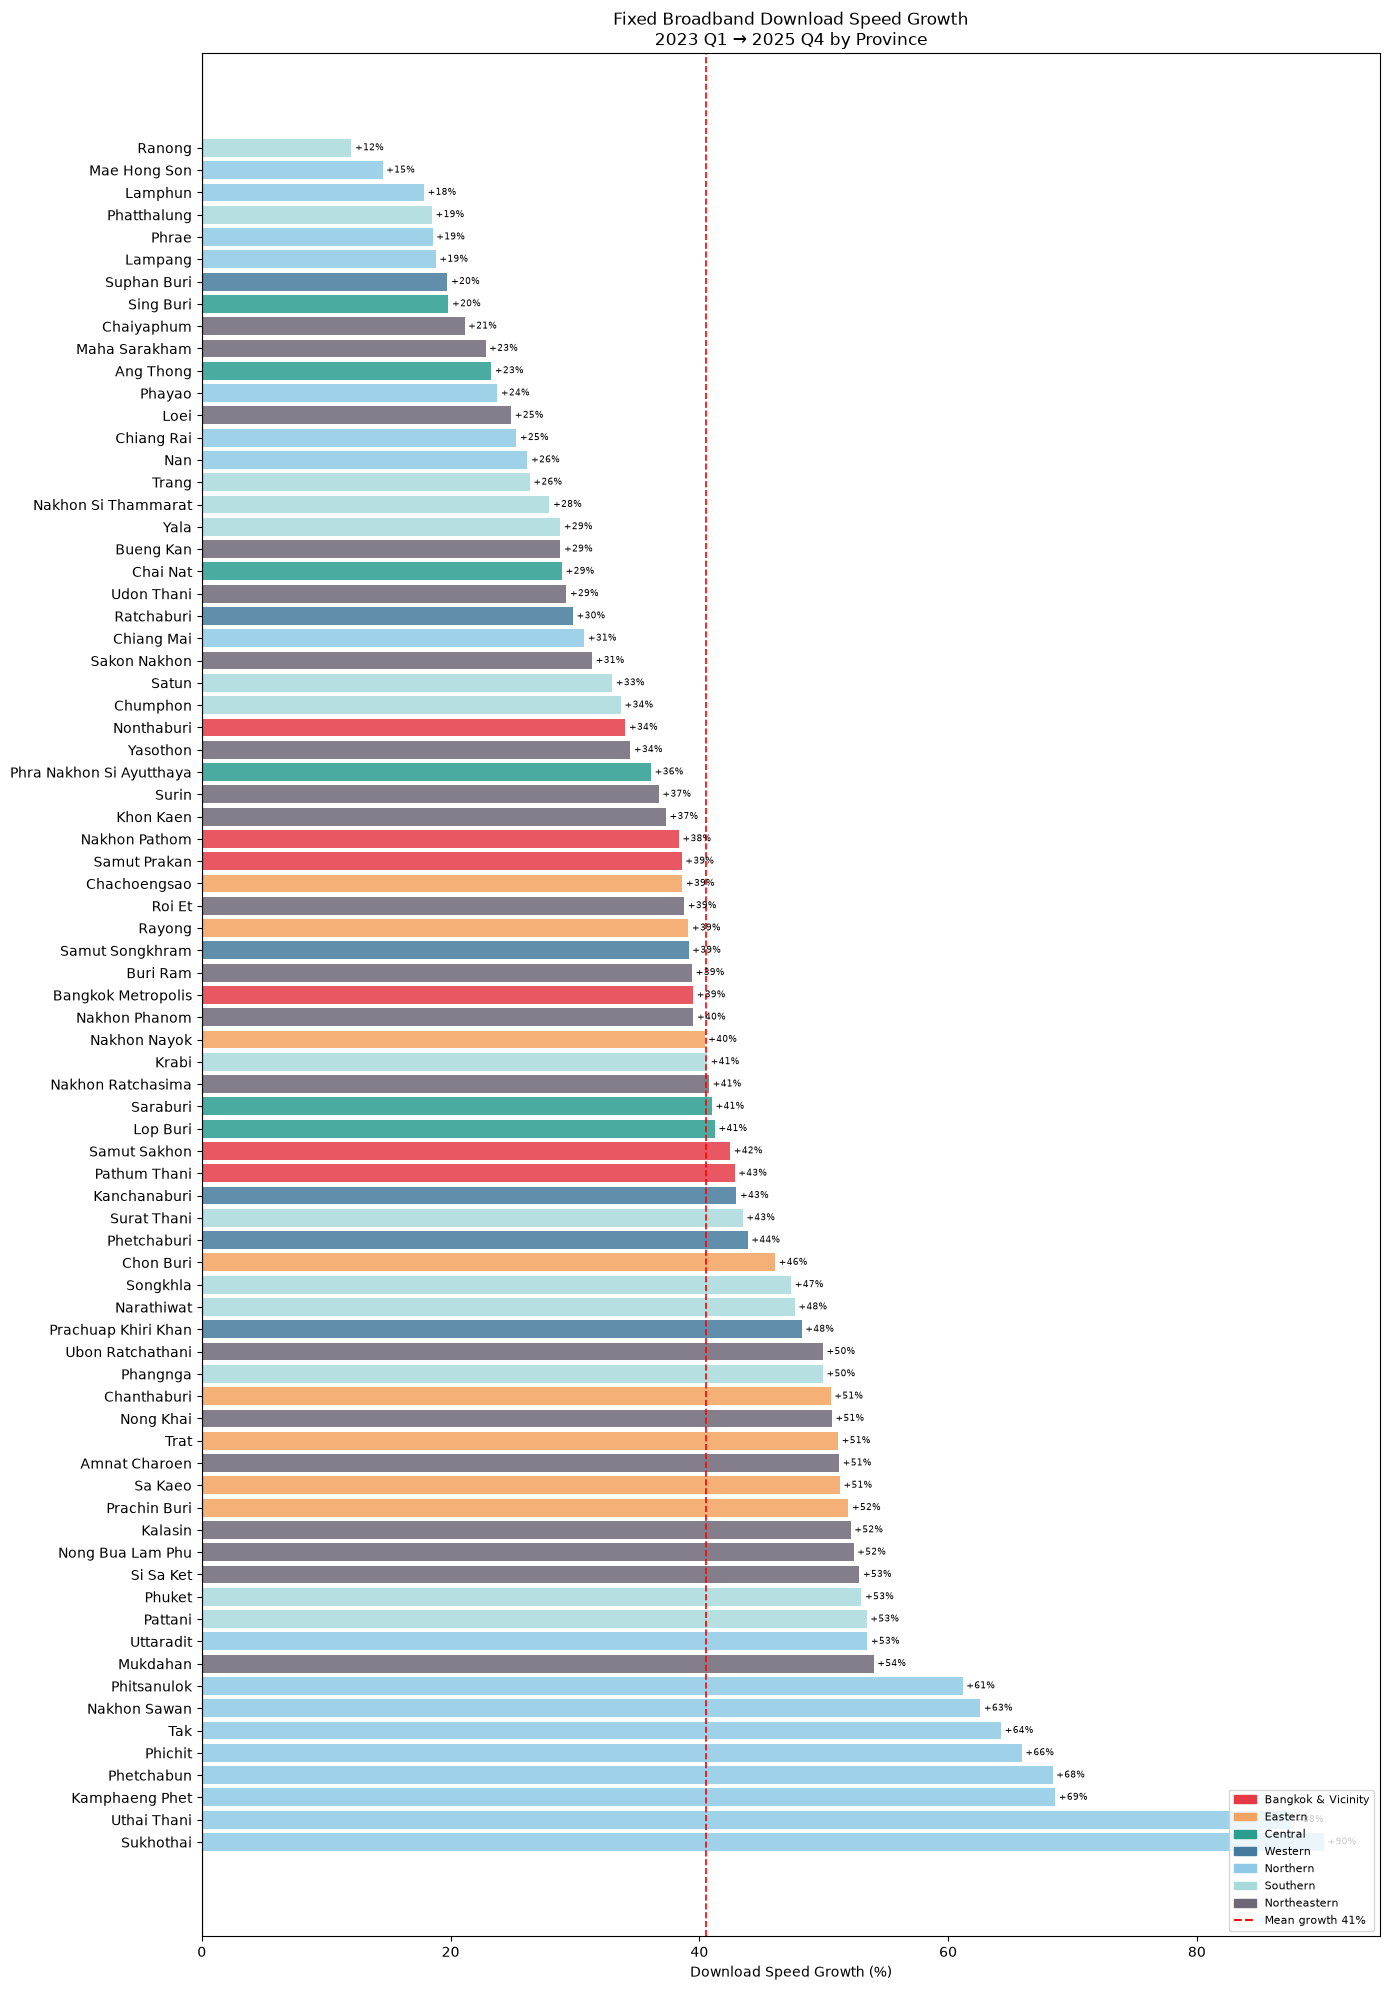

Top 10 fastest growing provinces:
          name       region  internet_tier  pct_growth
     Sukhothai     Northern              3   90.211210
   Uthai Thani     Northern              3   87.590317
Kamphaeng Phet     Northern              3   68.610470
    Phetchabun     Northern              3   68.397847
       Phichit     Northern              3   65.915823
           Tak     Northern              3   64.254773
  Nakhon Sawan     Northern              3   62.583810
   Phitsanulok     Northern              3   61.163803
      Mukdahan Northeastern              4   54.014858
     Uttaradit     Northern              3   53.499429

Bottom 5 (slowest growth or decline):
        name   region  internet_tier  pct_growth
      Ranong Southern              3   12.031291
Mae Hong Son Northern              4   14.528956
     Lamphun Northern              2   17.857854
 Phatthalung Southern              3   18.500883
       Phrae Northern              3   18.555045


In [33]:
first = master[master['label']=='2023-Q1'].set_index('name')['avg_d_mbps']
last  = master[master['label']=='2025-Q4'].set_index('name')['avg_d_mbps']
growth = ((last - first) / first * 100).dropna().sort_values(ascending=False)

growth_df = growth.reset_index()
growth_df.columns = ['name','pct_growth']
growth_df = growth_df.merge(prov_ref[['province_en','region','internet_tier']].rename(columns={'province_en':'name'}), on='name', how='left')

fig, ax = plt.subplots(figsize=(14, 20))
colors = [region_colors.get(r,'gray') for r in growth_df['region']]
bars = ax.barh(growth_df['name'], growth_df['pct_growth'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline(growth_df['pct_growth'].mean(), color='red', ls='--', lw=1.2,
           label=f"Mean growth {growth_df['pct_growth'].mean():.0f}%")
for bar, val in zip(bars, growth_df['pct_growth']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', fontsize=6.5)
patches = [mpatches.Patch(color=v,label=k) for k,v in region_colors.items()]
ax.legend(handles=patches+[plt.Line2D([0],[0],color='red',ls='--',label=f'Mean growth {growth_df["pct_growth"].mean():.0f}%')],
          fontsize=8, loc='lower right')
ax.set_xlabel('Download Speed Growth (%)')
ax.set_title('Fixed Broadband Download Speed Growth\n2023 Q1 → 2025 Q4 by Province', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 fastest growing provinces:")
print(growth_df.nlargest(10,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))
print("\nBottom 5 (slowest growth or decline):")
print(growth_df.nsmallest(5,'pct_growth')[['name','region','internet_tier','pct_growth']].to_string(index=False))


### 15. Deep Dive — The Weird Ones

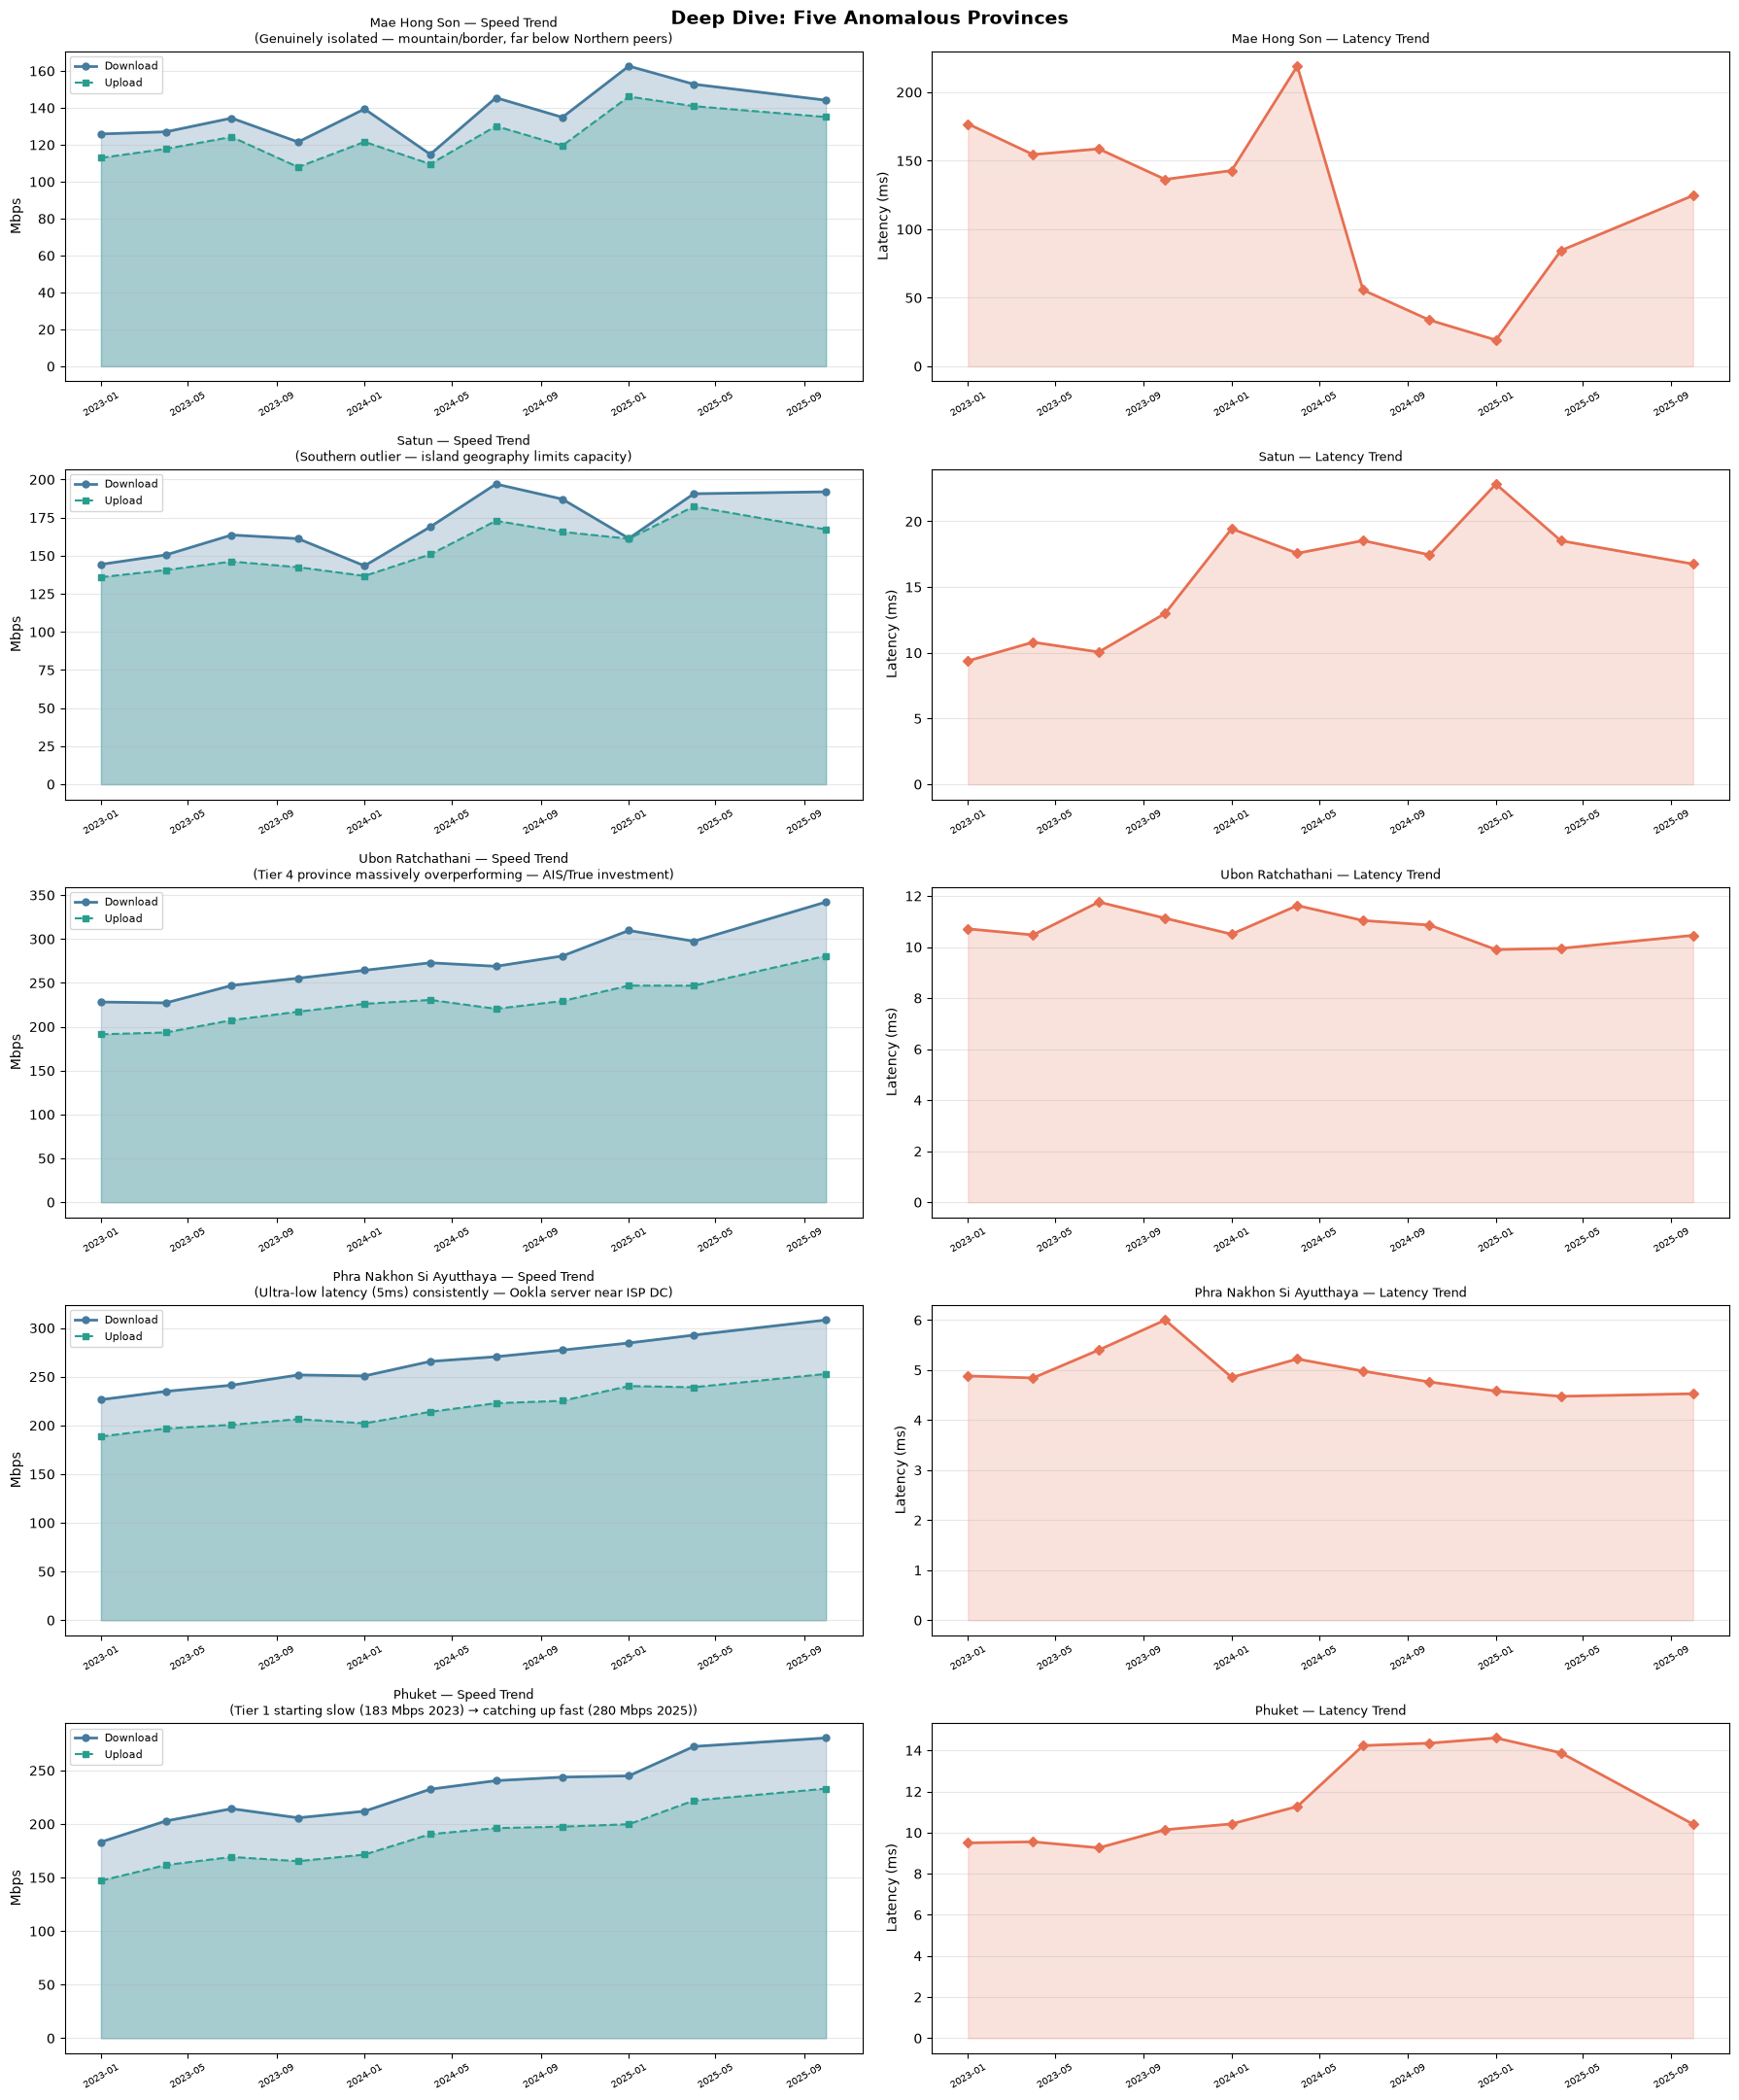

In [34]:
# Focus on 5 provinces that stand out most
WEIRD = {
    'Mae Hong Son':              'Genuinely isolated — mountain/border, far below Northern peers',
    'Satun':                     'Southern outlier — island geography limits capacity',
    'Ubon Ratchathani':          'Tier 4 province massively overperforming — AIS/True investment',
    'Phra Nakhon Si Ayutthaya':  'Ultra-low latency (5ms) consistently — Ookla server near ISP DC',
    'Phuket':                    'Tier 1 starting slow (183 Mbps 2023) → catching up fast (280 Mbps 2025)',
}

fig, axes = plt.subplots(len(WEIRD), 2, figsize=(18, 22))

quarter_order = sorted(master['label'].unique())

for ax_row, (prov, note) in zip(axes, WEIRD.items()):
    df_p = master[master['name']==prov].sort_values('label')
    
    # Download + upload trend
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_d_mbps'], alpha=0.25, color='#457b9d')
    ax_row[0].plot(df_p['period_start'], df_p['avg_d_mbps'], 'o-', color='#457b9d', label='Download', lw=2, markersize=5)
    ax_row[0].fill_between(df_p['period_start'], df_p['avg_u_mbps'], alpha=0.25, color='#2a9d8f')
    ax_row[0].plot(df_p['period_start'], df_p['avg_u_mbps'], 's--', color='#2a9d8f', label='Upload', lw=1.5, markersize=4)
    ax_row[0].set_title(f'{prov} — Speed Trend\n({note})', fontsize=9)
    ax_row[0].set_ylabel('Mbps'); ax_row[0].legend(fontsize=8); ax_row[0].grid(axis='y', alpha=0.3)
    ax_row[0].tick_params(axis='x', rotation=30, labelsize=7)
    
    # Latency trend
    ax_row[1].plot(df_p['period_start'], df_p['avg_lat_ms_wt'], 'D-', color='#e76f51', lw=2, markersize=5)
    ax_row[1].fill_between(df_p['period_start'], df_p['avg_lat_ms_wt'], alpha=0.2, color='#e76f51')
    ax_row[1].set_title(f'{prov} — Latency Trend', fontsize=9)
    ax_row[1].set_ylabel('Latency (ms)'); ax_row[1].grid(axis='y', alpha=0.3)
    ax_row[1].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Deep Dive: Five Anomalous Provinces', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 16. EDA Key Findings Summary

## Key Findings from EDA

### 1. Thai fixed broadband is more equal than GDP suggests
- Speed range: 137 Mbps (Mae Hong Son) to 317 Mbps (Nonthaburi) — only 2.3× gap
- Tier 1 median 282 Mbps vs Tier 4 median 229 Mbps — **23% gap despite 7× GDP difference**
- This contradicts the assumption that economic development drives broadband speed

### 2. Nationwide fiber deployment is the explanation
- **National mean UL/DL ratio = 0.852** — near-symmetric, a hallmark of GPON fiber
- 76 out of 77 provinces have UL/DL ratio > 0.80
- ADSL/cable would show 0.1–0.4 ratios; HFC cable 0.2–0.5
- **Bangkok metro has LOWER ratio (0.81) than rural provinces** — urban areas have legacy tech mixed in

### 3. Genuine geographic outliers
| Province | Avg DL | Why Weird |
|----------|--------|-----------|
| **Mae Hong Son** | 137 Mbps | Mountain/Myanmar border, lowest density (23/km²), consistently 100 Mbps below Northern peers |
| **Satun** | 169 Mbps | Island geography, Southern border, capacity-constrained backhaul |
| **Tak** | 181 Mbps | Large area (17,303 km²), low density, remote mountain terrain |

### 4. Surprising overperformers (Tier 4 beating Tier 2)
| Province | Avg DL | Context |
|----------|--------|---------|
| **Ubon Ratchathani** | 272 Mbps (+50% 2023→2025) | Largest Isaan city, AIS/True heavy investment |
| **Udon Thani** | 255 Mbps | Major Isaan hub, competitive fiber market |
| **Kalasin** | 259 Mbps | Smaller city, all-fiber rollout = no legacy drag |

### 5. Phuket: infrastructure lag story
- Started at 183 Mbps (2023 Q1) — below national average
- Rose to 280 Mbps (2025 Q4) — Tier 1 performance finally achieved
- Likely: tourist/seasonal demand forced ISP capacity upgrades

### 6. Ayutthaya latency artifact
- Consistent 4–5ms latency across all 11 quarters — suspiciously low
- Likely Ookla test server co-located with ISP datacenter in Ayutthaya/Bangkok axis
- Speeds are normal; latency does not reflect real user experience

### 7. Overall upward trend: Thailand broadband is improving
- National mean 2023 Q1 vs 2025 Q4: speeds increasing across the board
- No province showed consistent decline
